# Saliency Plots

In [1]:
from dna_features_viewer import BiopythonTranslator, GraphicFeature, GraphicRecord
from dna_features_viewer.biotools import annotate_biopython_record
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob, os, yaml, sparse, itertools, subprocess, sys, pickle

import Bio.SeqUtils
import Bio.Data
from Bio import SeqIO
from Bio.Seq import Seq

plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.titlepad'] = 10
import scipy.stats as st

# saliency_utils is in the utils_files directory
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "utils"))
from saliency_utils import *
from inSilicoMut_utils import *
from data_utils import *

from sklearn.linear_model import LinearRegression
BASE_TO_COLUMN = {'A': 0, 'C': 1, 'T': 2, 'G': 3, '-': 4}

data_path = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"
results_path = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"
vcf_dir = "/n/scratch3/users/s/sak0914/annotated_VCF"

# solo_results = pd.read_excel("/home/sak0914/who-analysis/data/SOLO primary_STATA_ver18Feb2023.xlsx", sheet_name="Sheet1")
who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")
who_variants["gene"] = [val.split("_")[0] for val in who_variants["mutation"].values]

coll_2014 = pd.read_csv("/home/sak0914/who-analysis/data/coll2014_SNP_scheme.tsv", sep="\t")
lineages = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineages.csv")
lineage_mat = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix_Coll2014.csv", index_col=[0])

# RIF_lineage_pred = pd.read_csv("../analysis/Rifampicin/insilico_mutagenesis/lineage_predictions.csv")
# MXF_lineage_pred = pd.read_csv("../analysis/Moxifloxacin/insilico_mutagenesis/lineage_predictions.csv")

h37Rv_path = "/n/data1/hms/dbmi/farhat/Sanjana/H37Rv"
h37Rv_seq = SeqIO.read(os.path.join(h37Rv_path, "GCF_000195955.2_ASM19595v2_genomic.gbff"), "genbank")
h37Rv_genes = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_genes_v4.csv"))
h37Rv_coords = pd.read_csv(os.path.join(h37Rv_path, "h37Rv_coords_to_gene.csv"))
h37Rv_coords_dict = dict(zip(h37Rv_coords["pos"].values, h37Rv_coords["region"].values))

4411532


# Pyrazinamide

In [2]:
def read_in_supplemental_file(fName, start, sense):

    df = pd.read_excel(fName, sheet_name=None)

    if len(df) == 1:
        df = df[list(df.keys())[0]]

    # supp1['POS'] = [int(val[1:-1]) for val in supp1.SNP.values]
    
    df = df.loc[df['Under-Represented?']=='N']
    del df['Under-Represented?']

    if "SNP" in df.columns:
        ref_lst = []
        alt_lst = []
        codon_lst = []
        pos_lst = []

        for snp in df['SNP'].values:
            ref_lst.append(snp[0].upper())
            alt_lst.append(snp[-1].upper())
            codon_lst.append(int(snp[1:-1]))

            if sense == '+':
                pos_lst.append(int(snp[1:-1]) - 1 + start)
            else:
                pos_lst.append(start - (int(snp[1:-1]) - 1))

        df['Codon'] = codon_lst
        df['POS'] = pos_lst
        df['REF'] = ref_lst
        df['ALT'] = alt_lst
            
    return df.reset_index(drop=True).fillna(0)

In [309]:
start = 2288681
end = 2289241

supp1 = read_in_supplemental_file("../analysis/Pyrazinamide/Yadon_2017_Supp1.xlsx", end, '-')

# does not contain discrepant (enriched in one replicate and depleted in another) mutations, which are present in supp1
supp2 = read_in_supplemental_file("../analysis/Pyrazinamide/Yadon_2017_Supp2.xlsx", end, '-')

supp2 = supp2.merge(supp1[['Codon', 'POS', 'REF', 'ALT', 'SNP', 'Substitution']], on='Substitution', how='outer')
print(supp1.shape, supp2.shape)

for col in supp2.columns:
    supp2.rename(columns={col: col.replace(" ", "_").replace(".", "")}, inplace=True)

supp2.to_csv("../analysis/Pyrazinamide/Yadon_2017_pncA_variants_V2.csv", index=False)

(1476, 10) (1476, 13)


In [310]:
pncA_variants_Yadon_2017 = pd.read_csv("../analysis/Pyrazinamide/Yadon_2017_pncA_variants_V2.csv")
print(pncA_variants_Yadon_2017.shape)
print(pncA_variants_Yadon_2017.POS.min(), pncA_variants_Yadon_2017.POS.max())

(1476, 13)
2288681 2289241


In [312]:
pncA_variants_Yadon_2017.query("in_vitro_Resistant == in_vitro_Susceptible").in_vitro_Resistant.unique()

array([0.])

In [313]:
pncA_variants_Yadon_2017.query("in_vivo_Resistant == in_vivo_Susceptible").in_vivo_Resistant.unique()

array([0.])

In [387]:
###### DO NOT RESET INDEX FOR PZA_pncA_SNP_saliency_df BECAUSE YOU NEED THE INDICES TO SLICE THE SCORES DATAFRAME
PZA_pncA_SNP_saliency_df = PZA_df.query("Gene=='pncA'")
PZA_pncA_SNP_saliency_df['Pos'] = PZA_pncA_SNP_saliency_df['Pos'].astype(str)
PZA_pncA_SNP_saliency_df = PZA_pncA_SNP_saliency_df.loc[(~pd.isnull(PZA_pncA_SNP_saliency_df['Pos'])) & (~PZA_pncA_SNP_saliency_df['Pos'].str.contains('_'))]
PZA_pncA_SNP_saliency_df['Pos'] = PZA_pncA_SNP_saliency_df['Pos'].astype(float).astype(int)
PZA_pncA_SNP_saliency_df.shape

(4742, 7)

In [389]:
i = 0
pncA_scores_by_nuc_df = pd.DataFrame(columns=['POS', 'REF', 'ALT', 'Max', 'Min'])

for pos in PZA_seqDict['pncA'].columns:
    # exclude indel sites so only those that are in H37Rv
    if '_' not in str(pos):

        ref_nuc = PZA_seqDict['pncA'].loc['MT_H37Rv', pos]
        pos_idx = PZA_pncA_SNP_saliency_df.query("Pos==@pos").index.values[0] 

        # check if there are non-REF sites that are also not indels. Indel analysis will be done separately
        if len(PZA_seqDict['pncA'].loc[~PZA_seqDict['pncA'][pos].isin([ref_nuc, '-', 'N'])]) > 0:

            pos = int(float(pos))

            # CNN was trained on additional sites outside of the pncA gene, so filter to keep only those in the coding region
            if pos >= start and pos <= end:

                max_scores = np.max(PZA_scores[:, :, pos_idx, 0], axis=0)
                max_scores = dict(zip(BASE_TO_COLUMN.keys(), max_scores))
    
                min_scores = np.min(PZA_scores[:, :, pos_idx, 0], axis=0)
                min_scores = dict(zip(BASE_TO_COLUMN.keys(), min_scores))

                # exclude alternative alleles that are indels or the same as the reference
                for alt_allele in PZA_seqDict['pncA'].loc[~PZA_seqDict['pncA'][pos].isin([ref_nuc, '-'])][pos].unique():
                    if alt_allele != 'N':
                        pncA_scores_by_nuc_df.loc[i, :] = [pos, ref_nuc, alt_allele, max_scores[alt_allele], min_scores[alt_allele]]
                        i += 1

print(pncA_scores_by_nuc_df.shape)

# only analyze (site, nucleotide pairs) with a non-zero score. Then we will analyze positive (enriched) and negative (depleted) scores separately
pncA_scores_by_nuc_df = pncA_scores_by_nuc_df.query("~(Max == 0 & Min == 0)")
print(pncA_scores_by_nuc_df.shape)

(135, 5)
(48, 5)


In [407]:
# 1/48 sites has a Max and a Min score, and they are about the same magnitude
# The exact nucleotide change is not in the Yadon dataframe (other changes at the same site are though), so it was probably inconclusive
resistance_combined_df = pncA_scores_by_nuc_df.query("Max != 0 & Min == 0").merge(pncA_variants_Yadon_2017, on=['POS', 'REF', 'ALT'], how='left').sort_values("POS")

susceptible_combined_df = pncA_scores_by_nuc_df.query("Min != 0 & Max == 0").merge(pncA_variants_Yadon_2017, on=['POS', 'REF', 'ALT'], how='left').sort_values("POS")

print(resistance_combined_df.shape, susceptible_combined_df.shape)

(42, 15) (5, 15)


In [408]:
# overlap between paper and CNN saliency results
resistance_combined_df.loc[~pd.isnull(resistance_combined_df['SNP'])].shape, susceptible_combined_df.loc[~pd.isnull(susceptible_combined_df['SNP'])].shape

((39, 15), (4, 15))

In [409]:
# sites with scores by CNN saliency only
resistance_combined_df.loc[pd.isnull(resistance_combined_df['SNP'])].shape, susceptible_combined_df.loc[pd.isnull(susceptible_combined_df['SNP'])].shape

((3, 15), (1, 15))

In [410]:
resistance_combined_df.loc[pd.isnull(resistance_combined_df['SNP'])]

,POS,REF,ALT,Max,Min,Substitution,in_vitro_Resistant,in_vitro_Susceptible,in_vivo_Resistant,in_vivo_Susceptible,Catalogue,Miotto_et_al,Walker_et_al,Codon,SNP
23,2288959,T,G,0.140427,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,2289016,A,C,1.14894,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2289207,A,C,0.451379,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [413]:
resistance_combined_df.loc[~pd.isnull(resistance_combined_df['SNP'])].sort_values("Max", ascending=False).Catalogue.value_counts()

Catalogue
E    26
0    10
D     3
Name: count, dtype: int64

In [406]:
pncA_variants_Yadon_2017.query("POS==2288764")

,Substitution,in_vitro_Resistant,in_vitro_Susceptible,in_vivo_Resistant,in_vivo_Susceptible,Catalogue,Miotto_et_al,Walker_et_al,Codon,POS,REF,ALT,SNP
1263,T160A,0.0,0.0,0.0,0.0,0,1.0,0.0,478,2288764,A,G,a478g
1267,T160S,0.0,1.0,0.0,1.0,D,0.0,0.0,478,2288764,A,T,a478t


In [405]:
pncA_scores_by_nuc_df.query("POS==2288958")

,POS,REF,ALT,Max,Min
75,2288958,A,C,0.043698,-0.046037


In [6]:
pos = 2288764
idx = PZA_pncA_SNP_saliency_df.query("Pos==@pos").index.values[0] 
print(f"Ref: {PZA_seqDict['pncA'].loc['MT_H37Rv', pos]}")
max_scores = np.max(PZA_scores[:, :, idx, 0], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), max_scores))

NameError: name 'PZA_pncA_SNP_saliency_df' is not defined

In [8]:
pos = 4040842
gene = 'clpC1'
locus_idx = ['pncA', 'panD', 'rpsA', 'clpC1'].index(gene)
idx = PZA_df.query("Gene==@gene").reset_index(drop=True).query("Pos==@pos").index.values[0]
print(f"Ref: {PZA_seqDict[gene].loc['MT_H37Rv', pos]}")
min_scores = np.min(PZA_scores[:, :, idx, locus_idx], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), min_scores))

Ref: G


{'A': 0.0, 'C': 0.0, 'T': 0.0, 'G': 0.0, '-': -2.3113291}

In [9]:
PZA_seqDict[gene].loc[PZA_seqDict[gene][pos] != 'G'][pos]

Isolate
Peru4687    -
Name: 4040842.0, dtype: object

In [10]:
PZA_df.query("Gene=='clpC1'").query("Pos==@pos")

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
11320,clpC1,4040842.0,0.0,-2.311329,0.0,1.0,0,0,0


In [21]:
PZA_df.query("Gene=='clpC1'").query("Pos in [4040802, 4040809]")

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
11353,clpC1,4040809.0,0.0,0.0,0.0,0.0,0,0,0
11360,clpC1,4040802.0,0.0,0.0,0.0,0.0,0,0,0


In [19]:
who_variants.query("drug=='PZA' & mutation.str.contains('clpC1') & genome_index.str.startswith('40408')")

,drug,genome_index,confidence,mutation,gene
6933,PZA,4040802,3) Uncertain significance,clpC1_c.-98C>G,clpC1
6934,PZA,4040802,3) Uncertain significance,clpC1_c.-98C>T,clpC1
7217,PZA,4040809,3) Uncertain significance,clpC1_c.-105G>A,clpC1


In [415]:
pncA_indels = PZA_df.query("Gene=='pncA'").loc[(~pd.isnull(PZA_df['Pos'])) & (PZA_df['Pos'].str.contains('_'))]
print(pncA_indels.shape)
# pncA_indels.query('Max_Sig == 1 | Min_Sig == 1')

(70, 7)


4 loci!
87 Cat 1 WHO catalog sites for PZA
23 Cat 1 WHO catalog sites not found
Sites not found: [2288697 2288704 2288709 2288775 2288790 2288805 2288817 2288818 2288820
 2288853 2288885 2289036 2289038 2289070 2289142 2289150 2289171 2289202
 2289213 2289220 2289222 2289223 2289240]


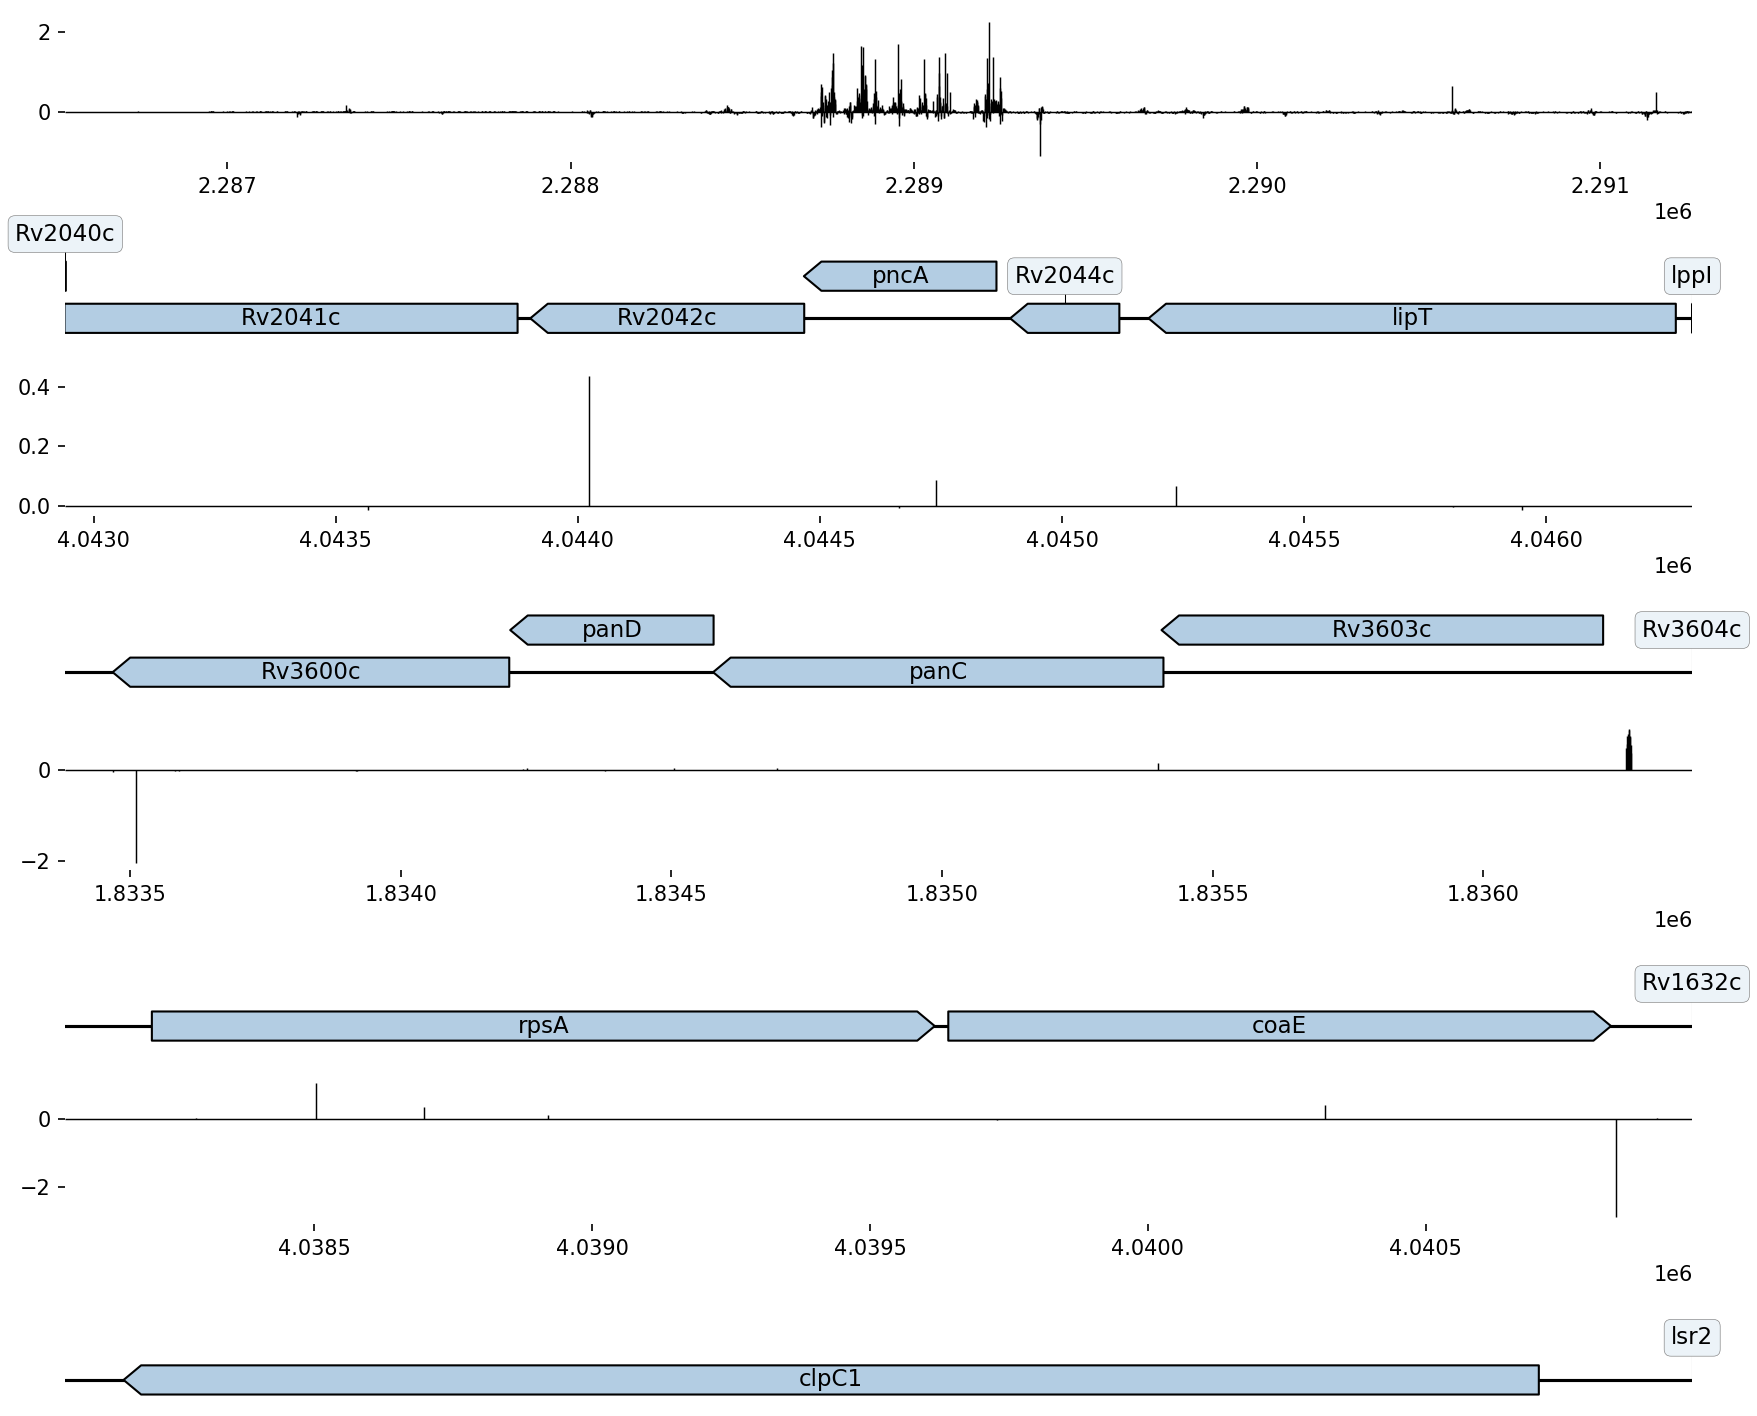

In [12]:
PZA_peptide_df, _ = generate_saliency_plots("PZA",
                                              os.path.join(results_path, "PZA_4Loci_peptide"),
                                              ['pncA', 'panD', 'rpsA', 'clpC1'],
                                              fasta_dir=data_path,
                                              cat_to_check=["1"],
                                              binary=False,
                                              save=True,
                                              significance=False,
                                              sig_thresh=0.05,
                                             )

# PZA_scores = sparse.load_npz(os.path.join(results_path, "PZA_4Loci_peptide/saliency/quant/genetic_scores_unpooled_nuc.npy.npz")).todense()

In [18]:
PZA_peptide_df.query("Pos==4038408")

,Gene,Pos,Max,Min,WHO,Coll_2014,Freschi_2020
13752,clpC1,4038410.0,0.0,0.0,0,0,0


In [22]:
PZA_df.query("Pos==4038406")

,Gene,Pos,Max,Min,WHO,Coll_2014,Freschi_2020
13756,clpC1,4038406.0,0.0,0.0,0,0,0


In [122]:
PZA_isolate_variants = pd.read_csv(os.path.join(data_path, "PZA", "isolate_variants.csv.gz"), compression='gzip')

In [24]:
PZA_isolate_variants = pd.read_csv(os.path.join(data_path, "PZA", "isolate_variants.csv.gz"), compression='gzip')

saliency_dir = os.path.join(results_path, "PZA_4Loci_peptide", "saliency", "quant")
locus_list = yaml.safe_load(open("../config_files/config_pza.yaml", "r"))['locus_list']

# get lineage scores for the primary model
mlp_scores = np.load(os.path.join(saliency_dir, "mlp_scores.npy"))

# create a dataframe with lineages, scores, and average log-MIC of isolates
mlp_scores_df = pd.DataFrame({"position": locus_list, 
                                  "Max": mlp_scores.max(axis=0), 
                                  "Min": mlp_scores.min(axis=0)
                                 })

# mlp_scores_paths = glob.glob(os.path.join(saliency_dir, "permutation_test/mlp_scores*.npy"))
# assert len(mlp_scores_paths) == 10

# mlp_permute_max = [pd.Series(np.load(scores_path).max(axis=0)) for scores_path in mlp_scores_paths]
# mlp_permute_max = pd.concat(mlp_permute_max, axis=1).values

# mlp_permute_min = [pd.Series(np.load(scores_path).min(axis=0)) for scores_path in mlp_scores_paths]
# mlp_permute_min = pd.concat(mlp_permute_min, axis=1).values

# for i, row in mlp_scores_df.iterrows():

#     # for scores of 0, the p-value is often 0 because all the permuted values are also 0. This is a misleading p-value, so ignore them
#     if row["Max"] > 0:
#         mlp_scores_df.loc[i, "Max_pval"] = np.mean(mlp_permute_max[i, :] > row["Max"])
#     else:
#         mlp_scores_df.loc[i, "Max_pval"] = np.nan

#     if row["Min"] < 0:
#         mlp_scores_df.loc[i, "Min_pval"] = np.mean(mlp_permute_min[i, :] < row["Min"])
#     else:
#         mlp_scores_df.loc[i, "Min_pval"] = np.nan

In [25]:
mlp_scores_df

,position,Max,Min
0,pncA,46.774445,-0.464896
1,panD,0.000000,0.000000
2,rpsA,0.018274,0.000000
3,clpC1,0.000000,0.000000


In [26]:
df_phenos = pd.read_csv(os.path.join(data_path, "PZA", "data_for_model.csv"))
locus_peptide_lengths = pd.read_csv(os.path.join(results_path, "PZA_4Loci", "locus_peptide_lengths.csv"), index_col=[0])

mlp_scores_by_isolate = pd.DataFrame(mlp_scores, index=df_phenos.ROLLINGDB_ID.values)
mlp_scores_by_isolate.columns = [f"{locus}_score" for locus in locus_list]

# .query("pncA_score > 0")
mlp_scores_by_isolate = mlp_scores_by_isolate.sort_values("pncA_score", ascending=False).merge(locus_peptide_lengths, left_index=True, right_index=True)

In [75]:
# all samples with a nonzero score for rpsA have the frameshift variant
mlp_scores_by_isolate.query('rpsA_score != 0').rpsA_length.unique(), mlp_scores_by_isolate.query('rpsA_score == 0').rpsA_length.unique()

(array([889.]), array([888.]))

In [37]:
# 1834985_insG not have any non-zero saliency scores, so all the prediction is coming from the rpsA peptide length
pos = 'rpsA_0'
locus = 'rpsA'
locus_list = ['pncA', 'panD', 'rpsA', 'clpC1']
locus_idx = locus_list.index(locus)

pos_idx = PZA_df.query("Gene == @locus").reset_index().query("Pos==@pos").index.values[0] 
print(f"Ref: {PZA_seqDict[locus].loc['MT_H37Rv', pos]}")
max_scores = np.max(PZA_scores[:, :, pos_idx, locus_idx], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), max_scores))

Ref: -


{'A': 0.0, 'C': 0.0, 'T': 0.0, 'G': 0.0, '-': 0.0}

In [76]:
seqDict = pickle.load(open(os.path.join(results_path, "PZA_4Loci", "seqDict.pkl"), "rb"))

In [108]:
Seq.Seq(''.join(seqDict['rpsA'].loc[:, 1833542:1834987].loc['Peru3257']).replace('-', '')).translate()

Seq('MPSPTVTSPQVAVNDIGSSEDFLAAIDKTIKYFNDGDIVEGTIVKVDRDEVLLD...SAW')

In [109]:
Seq.Seq(''.join(seqDict['rpsA'].loc[:, 1833542:1834987].loc['Peru5003']).replace('-', '')).translate()

Seq('MPSPTVTSPQVAVNDIGSSEDFLAAIDKTIKYFNDGDIVEGTIVKVDRDEVLLD...SA*')

In [94]:
len(''.join(seqDict['rpsA'].loc[:, 1833542:1834987].loc['Peru3257']).replace('-', ''))

1447

In [ ]:
TGA -> TGG A

In [99]:
Seq.Seq("TGA").translate(), Seq.Seq("TGG").translate()

(Seq('*'), Seq('W'))

In [115]:
search_isolates = mlp_scores_by_isolate.query('rpsA_score != 0').index.values

df_phenos.query("ROLLINGDB_ID in @search_isolates").PZA_midpoint.mean(), df_phenos.query("ROLLINGDB_ID not in @search_isolates").PZA_midpoint.mean()

(418.9102564102564, 209.81045081967213)

In [145]:
pncA_isolate_variants_search_isolates = PZA_isolate_variants.query("Isolate in @search_isolates & POS >= 2286527 & POS <= 2291268").reset_index(drop=True)

for i, row in pncA_isolate_variants_search_isolates.iterrows():
    
    if row['PROT'] != '.':
        pncA_isolate_variants_search_isolates.loc[i, "mutation"] = row["GENE"] + "_" + row["PROT"]
    else:
        pncA_isolate_variants_search_isolates.loc[i, "mutation"] = row["GENE"] + "_" + row["NUC"]
        
pncA_isolate_variants_search_isolates = pncA_isolate_variants_search_isolates.merge(who_variants.query("drug=='PZA'")[["confidence", "mutation"]], on="mutation", how="left")

In [148]:
pncA_isolate_variants_search_isolates.loc[~pd.isnull(pncA_isolate_variants_search_isolates['confidence'])].drop_duplicates("mutation")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation,confidence
3,2289213,T,C,PASS,1.0,pncA,missense_variant,c.29A>G,p.Gln10Arg,Peru2933,pncA_p.Gln10Arg,1) Assoc w R
137,2288839,T,G,PASS,1.0,pncA,missense_variant,c.403A>C,p.Thr135Pro,Peru4658,pncA_p.Thr135Pro,1) Assoc w R
140,2288834,A,AT,PASS,1.0,pncA,frameshift_variant,c.407dupA,p.Asp136fs,Peru5038,pncA_p.Asp136fs,2) Assoc w R - Interim


In [157]:
set(search_isolates) - set(pncA_isolate_variants_search_isolates.loc[~pd.isnull(pncA_isolate_variants_search_isolates['confidence'])].Isolate.unique())

{'Peru5129'}

In [158]:
pncA_isolate_variants_search_isolates.query("Isolate=='Peru5129'")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation,confidence
141,2287121,A,G,PASS,1.0,Rv2041c,synonymous_variant,c.726T>C,p.Asp242Asp,Peru5129,Rv2041c_p.Asp242Asp,NaN


In [ ]:
bcftools filter -i "POS >= 2286527 & POS <= 2291268" /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/Peru5129/pilon/Peru5129.eff.vcf

In [156]:
pncA_isolate_variants_search_isolates.loc[~pd.isnull(pncA_isolate_variants_search_isolates['confidence'])].mutation.value_counts()

mutation
pncA_p.Gln10Arg     36
pncA_p.Thr135Pro     1
pncA_p.Asp136fs      1
Name: count, dtype: int64

In [161]:
df_phenos.query("ROLLINGDB_ID == ['Peru5129']")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ID,ISOLATION_LOCATION,DB_OF_ORIGIN,STUDY_NAME,STUDY_PMID,TESTING_LOCATION,MEDIA,PZA,PZA_lower_bound,PZA_upper_bound,PZA_midpoint,Path,Coll2014,Binary,Lineage,category
955,Peru5129,SAMN05916441,Peru5129,Peru,farhat_internal,NaN,NaN,NJH,m7h10,50-100,50.0,100.0,75.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,4.1.1,0,4,original_train_set


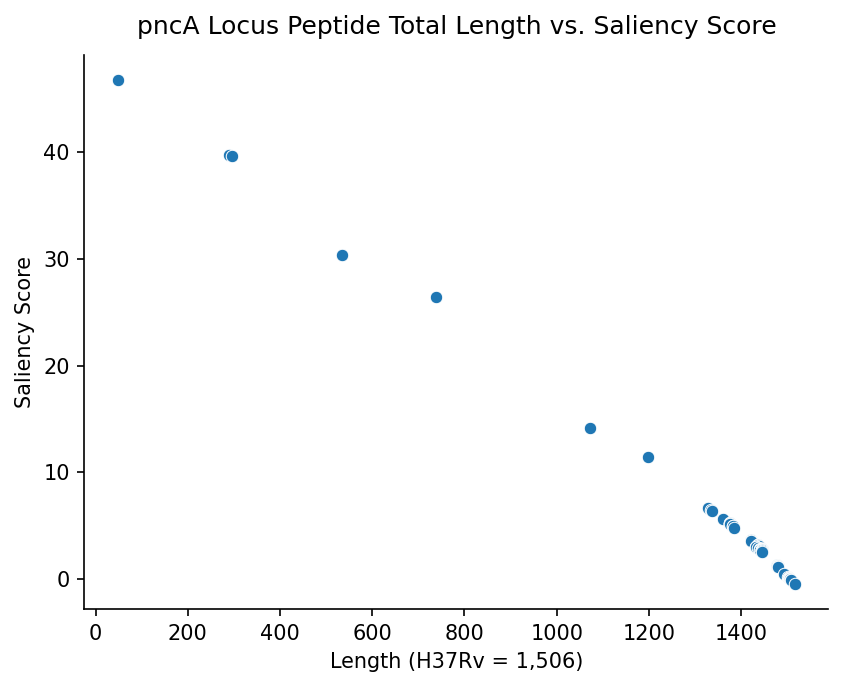

In [73]:
locus = 'pncA'
# say that because most (1008/1015, 99.3 %) of samples have lengths >= 1200, model probably didn't learn well enough about the relationship below that threshold
# 5/7 of the weird samples have positive saliency scores so still associated with R. Though I can't explain the other 2
sns.scatterplot(data=mlp_scores_by_isolate,
                x=f'{locus}_length',
                y=f'{locus}_score',
               )

# plt.axvline(1506, color='black', linestyle='--', linewidth=1, zorder=0)
plt.title("pncA Locus Peptide Total Length vs. Saliency Score")
plt.xlabel("Length (H37Rv = 1,506)")
plt.ylabel("Saliency Score")
sns.despine()
plt.show()

In [70]:
st.spearmanr(mlp_scores_by_isolate[f"{locus}_length"], mlp_scores_by_isolate[f"{locus}_score"])

SignificanceResult(statistic=-0.9999785023486508, pvalue=0.0)

In [65]:
st.pearsonr(mlp_scores_by_isolate[f"{locus}_length"], mlp_scores_by_isolate[f"{locus}_score"])

PearsonRResult(statistic=-0.9979873948933179, pvalue=0.0)

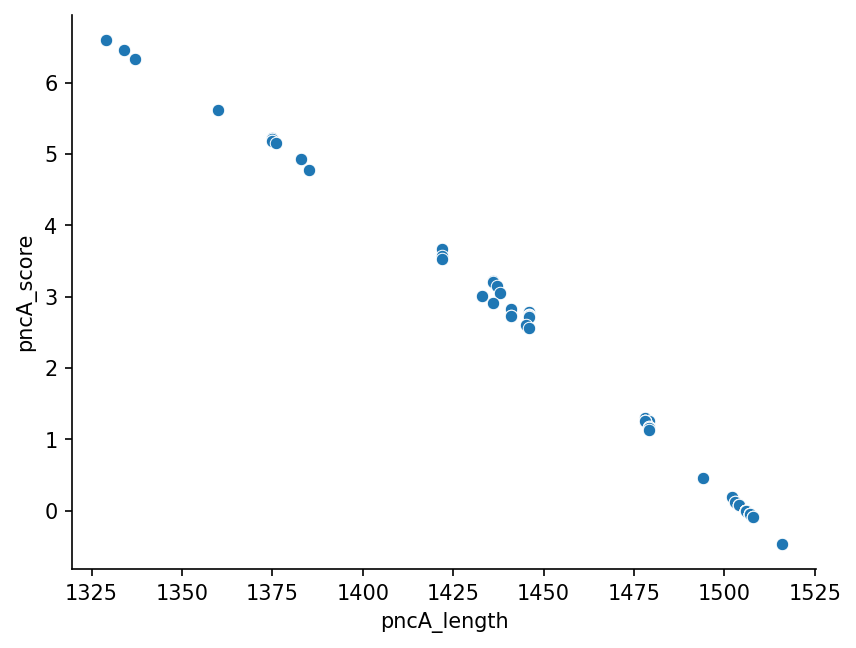

In [68]:
locus = 'pncA'
# say that because most (1008/1015, 99.3 %) of samples have lengths >= 1200, model probably didn't learn well enough about the relationship below that threshold
# 5/7 of the weird samples have positive saliency scores so still associated with R. Though I can't explain the other 2
sns.scatterplot(data=mlp_scores_by_isolate.query(f"{locus}_length >= 1300"),
                x=f'{locus}_length',
                y=f'{locus}_score',
               )
sns.despine()
plt.show()

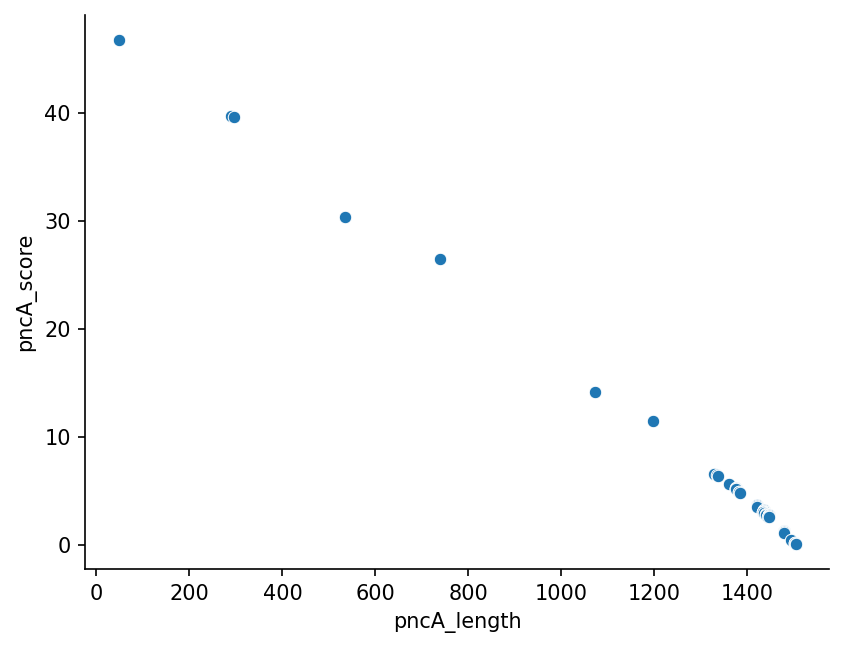

In [119]:
locus = 'pncA'
# say that because most (1008/1015, 99.3 %) of samples have lengths >= 1200, model probably didn't learn well enough about the relationship below that threshold
# 5/7 of the weird samples have positive saliency scores so still associated with R. Though I can't explain the other 2
sns.scatterplot(data=mlp_scores_by_isolate.query(f"{locus}_length < 1506"),
                x=f'{locus}_length',
                y=f'{locus}_score',
               )
sns.despine()
plt.show()

In [118]:
# full length or nonsense mutations
st.pearsonr(mlp_scores_by_isolate.query(f'{locus}_length < 1506')[f'{locus}_length'],
             mlp_scores_by_isolate.query(f'{locus}_length < 1506')[f'{locus}_score']
            )

PearsonRResult(statistic=-0.9990069940209456, pvalue=1.2839796609415647e-93)

4 loci!
87 Cat 1 WHO catalog sites for PZA
12 Cat 1 WHO catalog sites not found
Sites not found: [2288697 2288852 2288853 2288885 2288924 2288928 2289038 2289162 2289171
 2289202 2289206 2289223]


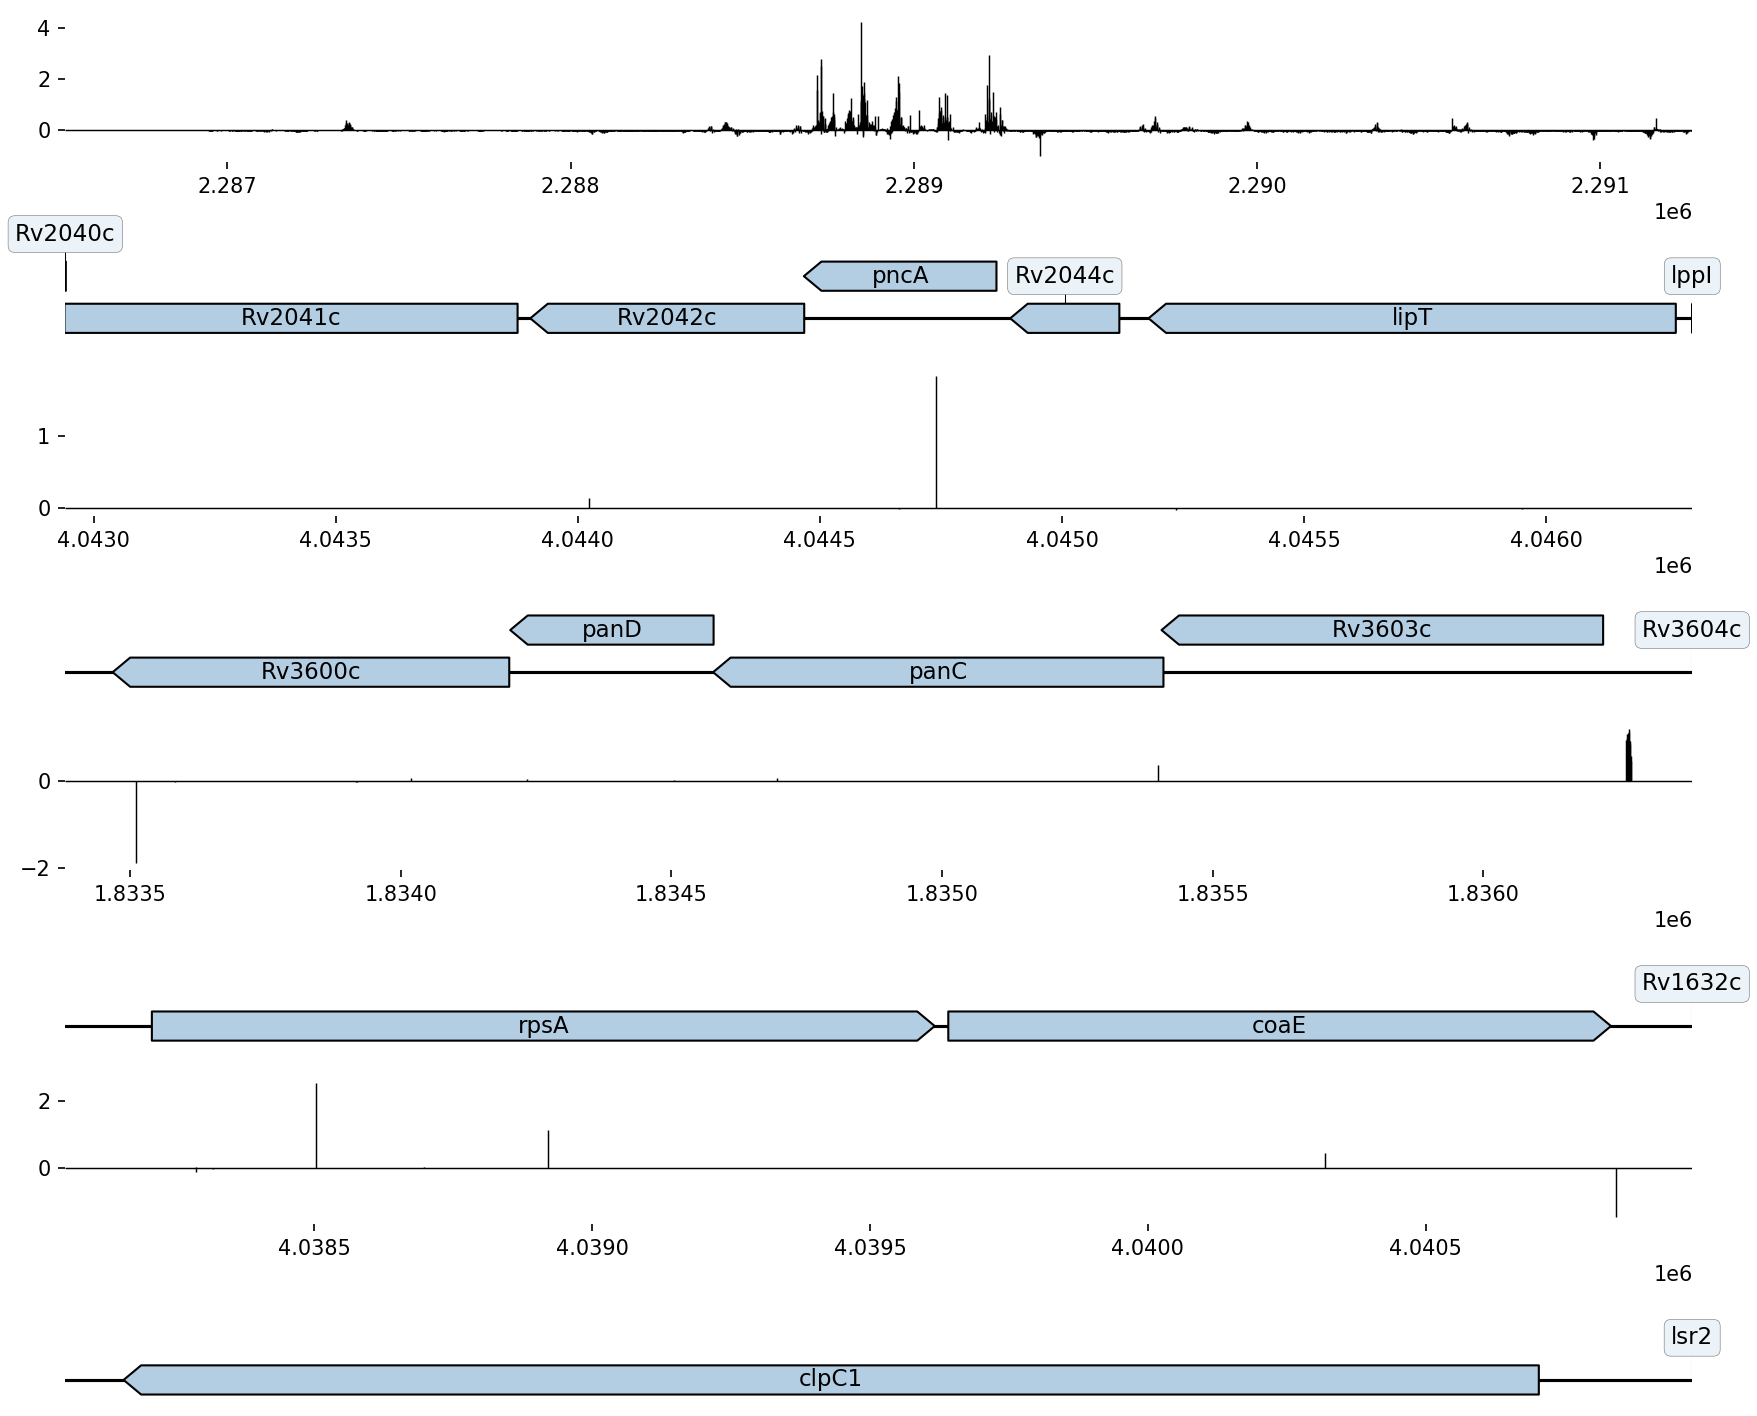

In [11]:
PZA_df, PZA_seqDict = generate_saliency_plots("PZA",
                                              os.path.join(results_path, "PZA_4Loci"),
                                              ['pncA', 'panD', 'rpsA', 'clpC1'],
                                              fasta_dir=data_path,
                                              cat_to_check=["1"],
                                              binary=False,
                                              save=True,
                                              significance=False,
                                              sig_thresh=0.05,
                                             )

# PZA_scores = sparse.load_npz(os.path.join(results_path, "PZA_4Loci/saliency/quant/genetic_scores_unpooled_nuc.npy.npz")).todense()
# print(PZA_scores.shape)

# PZA_seqDict["pncA"].to_csv("/home/sak0914/MtbQuantCNN/analysis/Pyrazinamide/pncA_seqdf.csv")
# pickle.dump(PZA_seqDict, open("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_4Loci/seqDict.pkl", "wb"))

In [428]:
4040704+138

4040842

In [429]:
PZA_df.query("Gene=='clpC1' & (Max_Sig == 1 | Min_Sig == 1)").sort_values("Pos", ascending=True)

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
13875,clpC1,4038287.0,0.123326,0.000000,1.0,0.0,0,0,0
13844,clpC1,4038318.0,0.002404,0.000000,1.0,0.0,0,0,0
13659,clpC1,4038503.0,1.841347,0.000000,1.0,0.0,0,0,0
13464,clpC1,4038698.0,0.045139,0.000000,1.0,0.0,0,0,0
13241,clpC1,4038921.0,1.210866,0.000000,1.0,0.0,0,0,0
12433,clpC1,4039729.0,0.000000,-0.013459,0.0,1.0,0,0,0
11998,clpC1,4040164.0,0.000000,-0.008246,0.0,1.0,0,0,0
11844,clpC1,4040318.0,0.464219,0.000000,1.0,0.0,0,0,0
11692,clpC1,4040470.0,0.000000,-0.008236,0.0,1.0,0,0,0
11320,clpC1,4040842.0,0.000000,-1.153629,0.0,1.0,0,0,0


In [10]:
# PZA_lineage_df, _ = generate_saliency_plots("PZA",
#                                           os.path.join(results_path, "PZA_4Loci_lineage"),
#                                           ['pncA', 'panD', 'rpsA', 'clpC1'],
#                                           fasta_dir=data_path,
#                                           cat_to_check=["1"],
#                                           binary=False,
#                                           save=True,
#                                           significance=True,
#                                           sig_thresh=0.05,
#                                          )

# PZA_lineage_scores = sparse.load_npz(os.path.join(results_path, "PZA_4Loci_lineage/saliency/quant/genetic_scores_unpooled_nuc.npy.npz")).todense()

In [3]:
# pos = 1834965
# gene = "rpsA"
# pos_idx = list(PZA_seqDict[gene].columns).index(pos)
# gene_idx = list(PZA_seqDict.keys()).index(gene)

# print(f"Ref: {PZA_seqDict[gene].loc['MT_H37Rv', pos]}")
# max_scores = np.max(PZA_lineage_scores[:, :, pos_idx, gene_idx], axis=0)
# dict(zip(BASE_TO_COLUMN.keys(), max_scores))

# # GA 1834964 > G

In [3]:
PZA_saliency_variants_df = extract_saliency_score_variant_types(PZA_lineage_df, PZA_seqDict, PZA_lineage_scores, max_scores=True)

Extracting saliency score variants for pncA
Extracting saliency score variants for panD
Extracting saliency score variants for rpsA
Extracting saliency score variants for clpC1


In [21]:
# pos = "pncA_28"
# gene = "pncA"
# pos_idx = list(PZA_seqDict[gene].columns).index(pos)
# gene_idx = list(PZA_seqDict.keys()).index(gene)

# print(f"Ref: {PZA_seqDict[gene].loc['MT_H37Rv', pos]}")
# # max_scores = np.max(PZA_lineage_scores[:, :, pos_idx, gene_idx], axis=0)
# # dict(zip(BASE_TO_COLUMN.keys(), max_scores))

# scores_df = pd.DataFrame({"Nuc": BASE_TO_COLUMN.keys(), "Score": np.max(PZA_lineage_scores[:, :, pos_idx, gene_idx], axis=0)})
# scores_df

# Rifampicin

2 loci!
Plotting significant saliency scores for rpoBC using 10 max scores and 10 min scores
Plotting significant saliency scores for rpoA using 10 max scores and 10 min scores
17 Cat 1 WHO catalog sites for RIF
2 Cat 1 WHO catalog sites not found
Sites not found: [761134 761156]


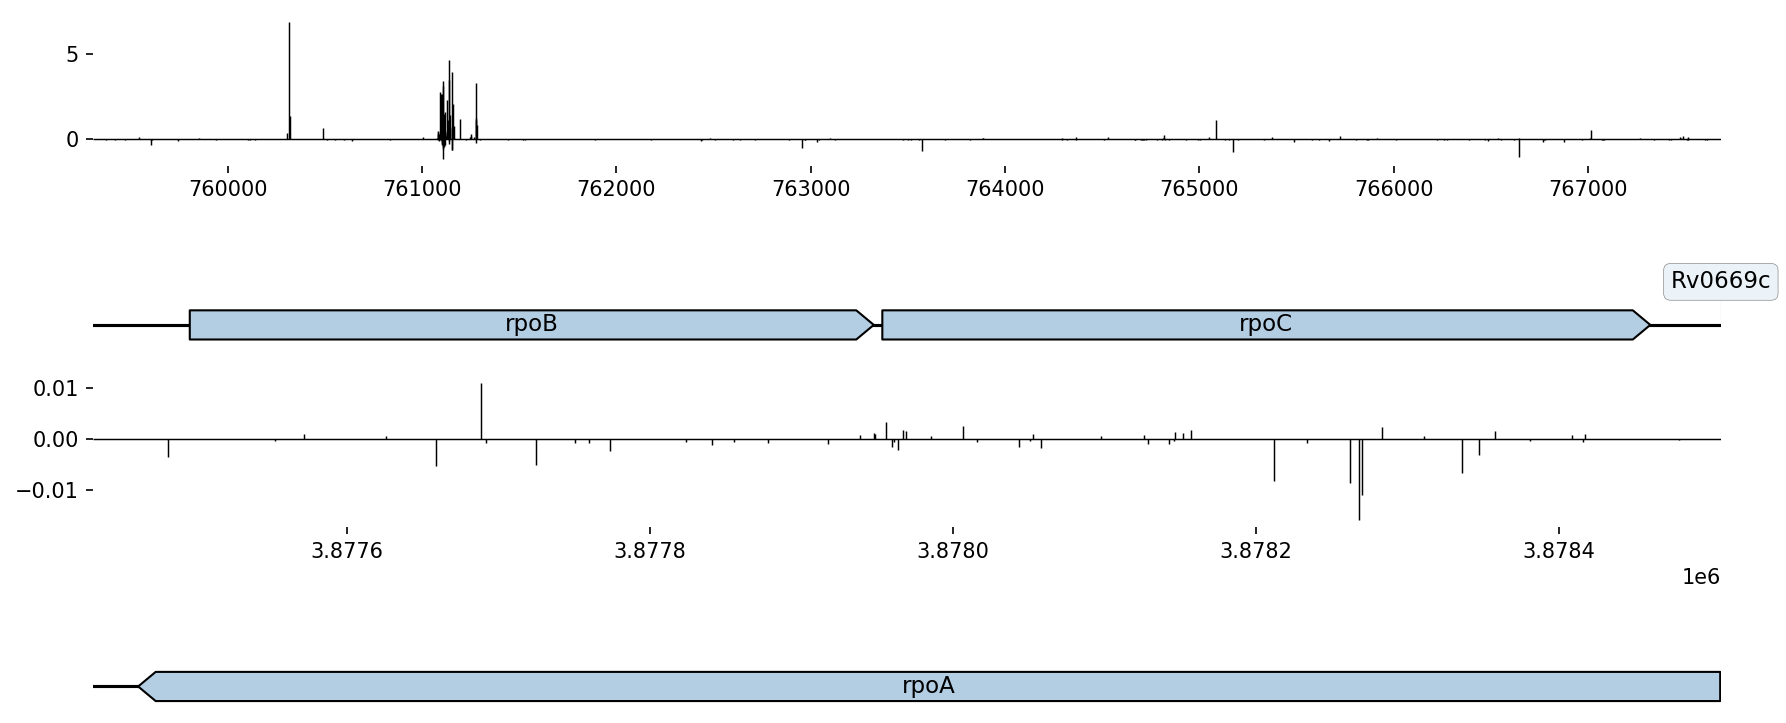

In [17]:
RIF_rpoABC_df, rpoABC_seqDict = generate_saliency_plots(drug="RIF",
                                                        out_dir=os.path.join(results_path, "RIF_rpoABC"),
                                                        locus_list=["rpoBC", "rpoA"],
                                                        fasta_dir=data_path,
                                                        cat_to_check=["1"],
                                                        binary=False,
                                                        save=True,
                                                        significance=True,
                                                        sig_thresh=0.05,
                                                      )


RIF_rpoABC_scores = sparse.load_npz(os.path.join(results_path, "RIF_rpoABC/saliency/quant/genetic_scores_unpooled_nuc.npy.npz")).todense()

# saliency_save = RIF_rpoBC_df.copy()
# del saliency_save["Coll_2014"]
# del saliency_save["Freschi_2020"]
# del saliency_save["WHO"]
# saliency_save.to_csv("../analysis/Rifampicin/rpoBC_saliency_results.csv", index=False)

RIF_rpoABC_df.to_csv("/home/sak0914/MtbQuantCNN/analysis/Rifampicin/rpoABC_saliency_results.csv", index=False)
rpoABC_seqDict["rpoBC"].to_csv("/home/sak0914/MtbQuantCNN/analysis/Rifampicin/rpoBC_seqdf.csv")

In [19]:
pos = 761134
idx = RIF_rpoABC_df.query("Pos==@pos").index.values[0] 
print(f"Ref: {rpoABC_seqDict['rpoBC'].loc['MT_H37Rv', pos]}")
max_scores = np.max(RIF_rpoABC_scores[:, :, idx, 0], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), max_scores))

Ref: T


{'A': 0.0, 'C': 0.0, 'T': 0.0, 'G': 0.0, '-': 0.0}

In [18]:
pos = 761156
idx = RIF_rpoABC_df.query("Pos==@pos").index.values[0] 
print(f"Ref: {rpoABC_seqDict['rpoBC'].loc['MT_H37Rv', pos]}")
max_scores = np.max(RIF_rpoABC_scores[:, :, idx, 0], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), max_scores))

Ref: G


{'A': 0.0, 'C': 0.0, 'T': 0.0, 'G': 0.0, '-': 0.0}

In [16]:
RIF_rpoABC_df.query("Pos in [761154, 761155]")

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
1897,rpoBC,761154.0,0.662114,-0.862931,1.0,1.0,1,0,0
1898,rpoBC,761155.0,3.336931,0.000000,1.0,0.0,1,0,0


In [17]:
who_variants.query("drug=='RIF' & confidence=='1) Assoc w R' & genome_index.str.contains('761156')")

,drug,genome_index,confidence,mutation,gene
74,RIF,"761155,761156",1) Assoc w R,rpoB_p.Ser450Phe,rpoB


# Moxifloxacin

1 loci!
Plotting significant saliency scores for gyrBA using 10 max scores and 10 min scores
11 Cat 1/2 WHO catalog sites for MXF
1 Cat 1/2 WHO catalog sites not found
Sites not found: [7564]


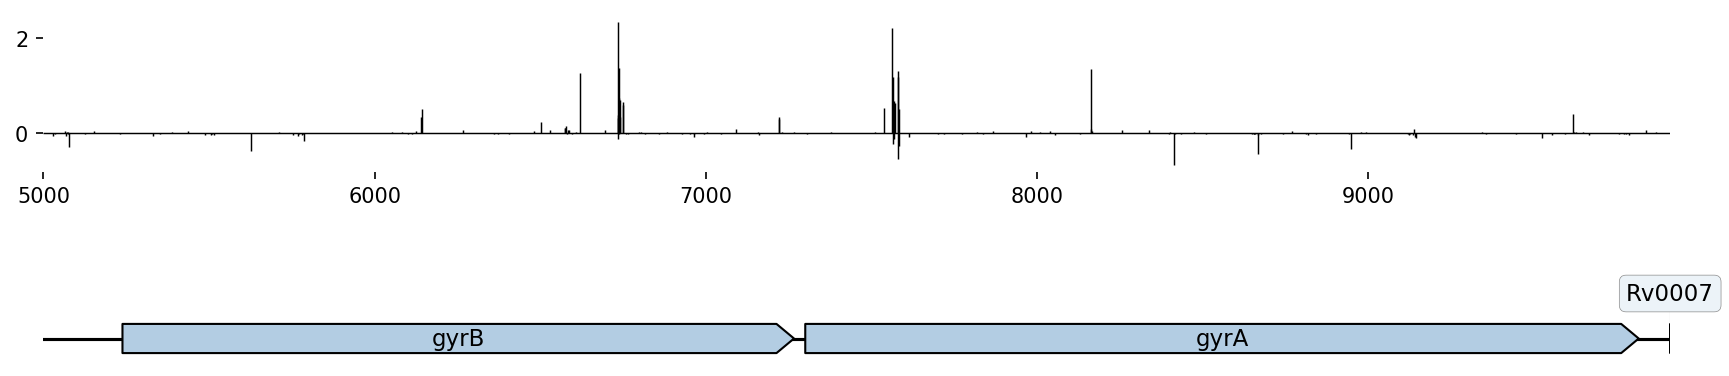

In [11]:
_, _ = generate_saliency_plots(drug="MXF",
                                                        out_dir=os.path.join(results_path, "MXF_gyrBA"),
                                                        locus_list=["gyrBA"],
                                                        fasta_dir=data_path,
                                                        cat_to_check=["1", "2"],
                                                        binary=False,
                                                        save=True,
                                                        significance=True,
                                                        sig_thresh=0.05,
                                                      )

1 loci!
Plotting significant saliency scores for gyrBA using 10 max scores and 10 min scores
11 Cat 1/2 WHO catalog sites for MXF
1 Cat 1/2 WHO catalog sites not found
Sites not found: [7564]


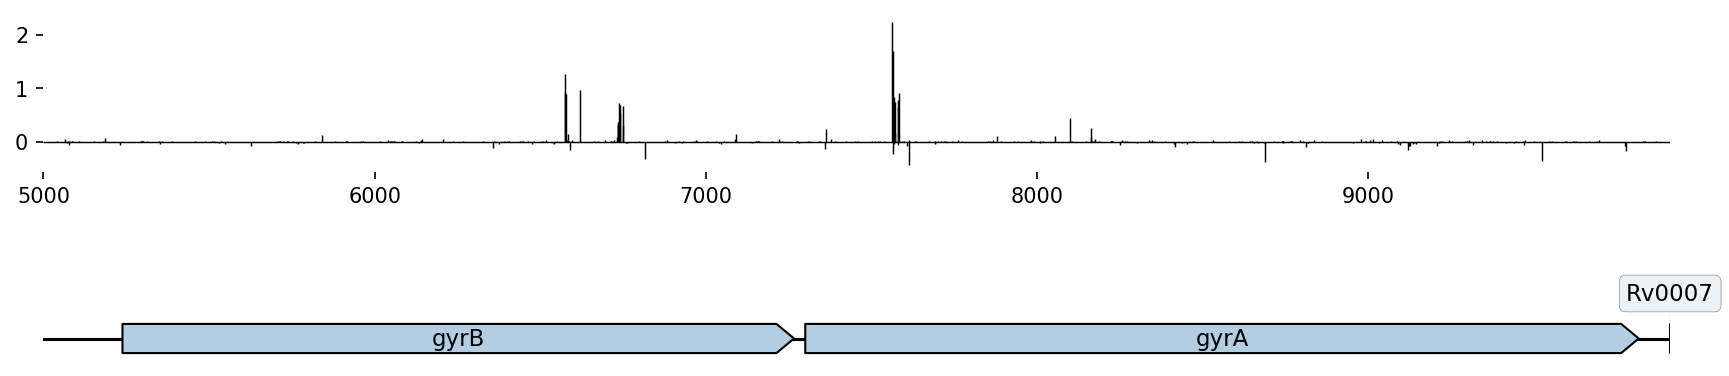

In [2]:
MXF_gyrBA_lineage_df, MXF_gyrBA_seqDict = generate_saliency_plots(drug="MXF",
                                                        out_dir=os.path.join(results_path, "MXF_gyrBA_lineage"),
                                                        locus_list=["gyrBA"],
                                                        fasta_dir=data_path,
                                                        cat_to_check=["1", "2"],
                                                        binary=False,
                                                        save=True,
                                                        significance=True,
                                                        sig_thresh=0.05,
                                                      )

MXF_gyrBA_lineage_scores = sparse.load_npz(os.path.join(results_path, "MXF_gyrBA_lineage/saliency/quant/genetic_scores_unpooled_nuc.npy.npz")).todense()

MXF_gyrBA_lineage_df.to_csv("/home/sak0914/MtbQuantCNN/analysis/Moxifloxacin/gyrBA_lineage_saliency_results.csv", index=False)
MXF_gyrBA_seqDict['gyrBA'].to_csv("/home/sak0914/MtbQuantCNN/analysis/Moxifloxacin/gyrBA_seqdf.csv")

In [4]:
MXF_gyrBA_lineage_df.query("Pos in [7570, 7539]")

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
2553,gyrBA,7539.0,0.001628,0.0,1.0,0.0,0,0,0
2584,gyrBA,7570.0,0.840608,0.0,1.0,0.0,1,0,0


In [5]:
# Ala90: The only variant at 7570 is C>T, which is A90V (1. Assoc w R)
# A90G (C>G) is a category 4) Not assoc w R - interim variant
pos = 7570
idx = MXF_gyrBA_lineage_df.query("Pos==@pos").index.values[0] 
print(f"Ref: {MXF_gyrBA_seqDict['gyrBA'].loc['MT_H37Rv', pos]}")
max_scores = np.max(MXF_gyrBA_lineage_scores[:, :, idx, 0], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), max_scores))

Ref: C


{'A': 0.0, 'C': 0.0, 'T': 0.8406082, 'G': 0.0, '-': 0.0}

In [7]:
MXF_gyrBA_seqDict['gyrBA'][pos].value_counts()

7570.0
C    7037
T     280
N      38
Name: count, dtype: int64

In [ ]:
bcftools filter -i "POS==7570" /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/ERR2184436/pilon/ERR2184436.eff.vcf

In [9]:
MXF_gyrBA_seqDict['gyrBA'].loc[MXF_gyrBA_seqDict['gyrBA'][pos]=='N'][pos]

Isolate
ERR4810972        N
ERR4811119        N
ERR4810463        N
ERR4810482        N
ERR4822586        N
ERR4822596        N
ERR4831008        N
ERR4831016        N
ERR4831026        N
ERR4796512        N
ERR4797377        N
ERR4797324        N
ERR4812331        N
ERR4813048        N
ERR4812970        N
ERR3287689        N
ERR3287435        N
ERR3287852        N
ERR3287856        N
ERR2184245        N
ERR2184436        N
ERR4828779        N
ERR5917667        N
ERR2510394        N
ERR4829124        N
ERR2510616        N
ERR2510543        N
ERR4831966        N
01R1241           N
02R0951           N
Peru4039          N
Peru4698          N
Peru4740          N
Peru5070          N
Peru5112          N
Peru5437          N
TDR229S201L002    N
TDR235S207L002    N
Name: 7570.0, dtype: object

# Levofloxacin

1 loci!
Plotting significant saliency scores for gyrBA using 10 max scores and 10 min scores
11 Cat 1/2 WHO catalog sites for LEV
2 Cat 1/2 WHO catalog sites not found
Sites not found: [6620 6734]


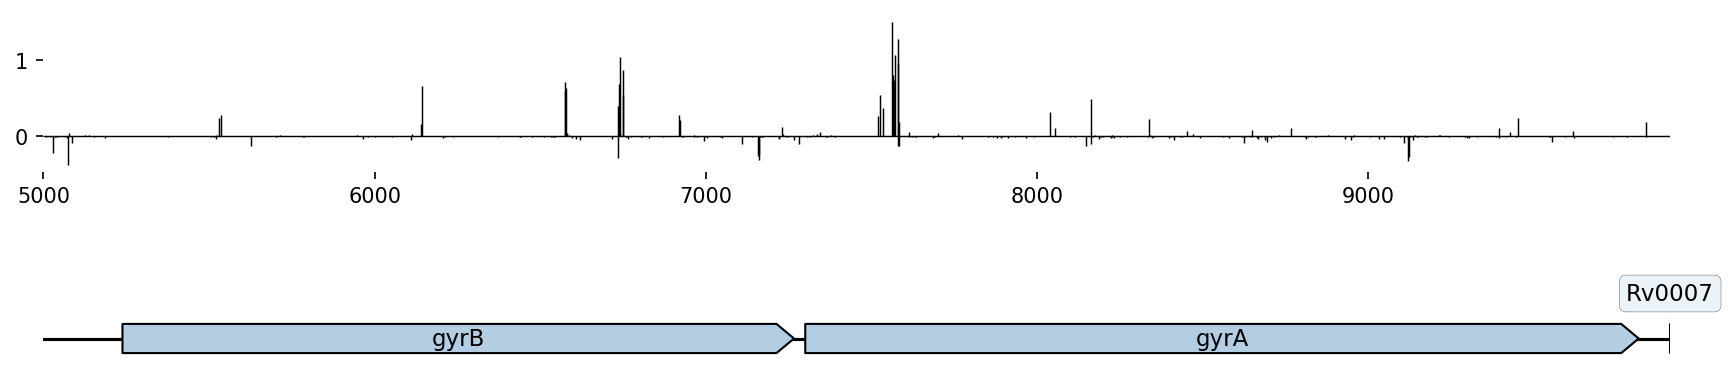

In [13]:
LEV_gyrBA_df, LEV_gyrBA_seqDict = generate_saliency_plots(drug="LEV",
                                                        out_dir=os.path.join(results_path, "LEV_gyrBA"),
                                                        locus_list=["gyrBA"],
                                                        fasta_dir=data_path,
                                                        cat_to_check=["1", "2"],
                                                        binary=False,
                                                        save=True,
                                                        significance=True,
                                                        sig_thresh=0.05,
                                                      )

# LEV_gyrBA_scores = sparse.load_npz(os.path.join(results_path, "LEV_gyrBA/saliency/quant/genetic_scores_unpooled_nuc.npy.npz")).todense()

1 loci!
Plotting significant saliency scores for gyrBA using 10 max scores and 10 min scores
11 Cat 1/2 WHO catalog sites for LEV
1 Cat 1/2 WHO catalog sites not found
Sites not found: [6734]


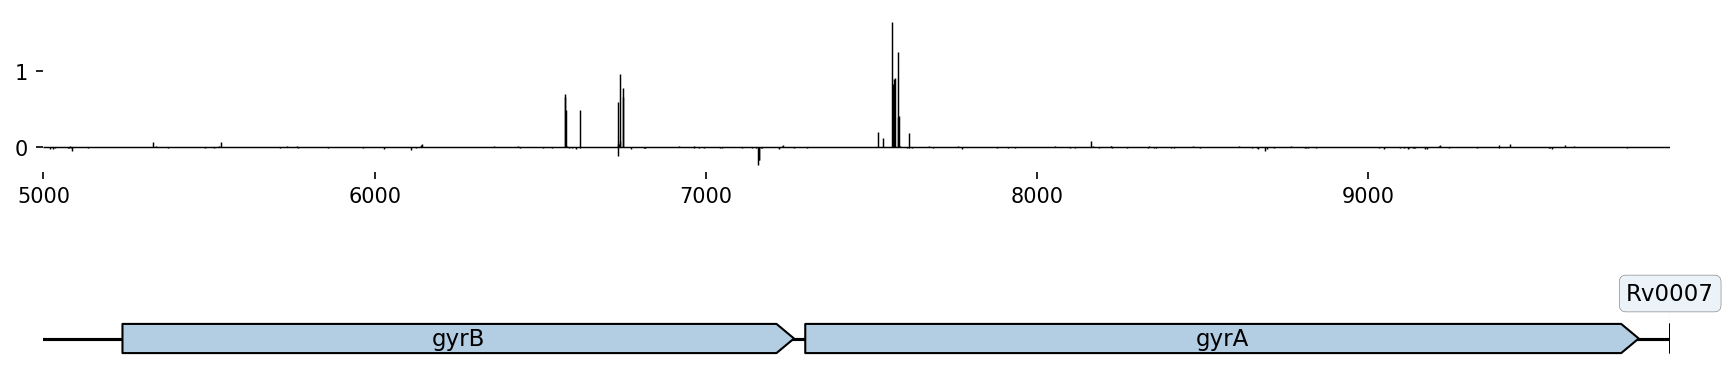

In [14]:
_, _ = generate_saliency_plots(drug="LEV",
                                                        out_dir=os.path.join(results_path, "LEV_gyrBA_lineage"),
                                                        locus_list=["gyrBA"],
                                                        fasta_dir=data_path,
                                                        cat_to_check=["1", "2"],
                                                        binary=False,
                                                        save=True,
                                                        significance=True,
                                                        sig_thresh=0.05,
                                                      )

In [108]:
def get_lengths(drug):

    regression_saliency_df = pd.read_csv(f"../regression/{drug}_saliency.csv")

    a = len(regression_saliency_df.query("~feature.str.contains('lineage')"))
    b = len(regression_saliency_df.query("~feature.str.contains('lineage') & pval < 0.05"))
    print(a, b, b/a)

# Indels with High Positive Scores

In [120]:
RIF_isolate_variants.query("Isolate=='ERR4828591'")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation,RIF_midpoint,category,new_variant
13667,759627.0,A,ACTTGACACCGTGGTCTTAGTC,PASS,0.46,mazF2,upstream_gene_variant,c.-4635_-4634insGACTAAGACCACGGTGTCAAG,.,ERR4828591,mazF2_c.-4635_-4634insGACTAAGACCACGGTGTCAAG,0.03,train,c.-4635_-4634insGACTAAGACCACGGTGTCAAG
13668,759648.0,C,CCTTGACACCGTGGTCTTAGTC,PASS,0.76,mazF2,upstream_gene_variant,c.-4656_-4655insGACTAAGACCACGGTGTCAAG,.,ERR4828591,mazF2_c.-4656_-4655insGACTAAGACCACGGTGTCAAG,0.03,train,c.-4656_-4655insGACTAAGACCACGGTGTCAAG
13669,763031.0,T,C,PASS,1.00,rpoB,synonymous_variant,c.3225T>C,p.Ala1075Ala,ERR4828591,rpoB_c.3225T>C,0.03,train,c.3225T>C


In [123]:
df_rif.query("ROLLINGDB_ID=='ERR4828591'")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ID,ISOLATION_LOCATION,DB_OF_ORIGIN,STUDY_NAME,STUDY_PMID,TESTING_LOCATION,MEDIA,RIF,RIF_lower_bound,RIF_midpoint,RIF_upper_bound,RIF_quality,Path,Coll2014,Binary,Lineage,category
6801,ERR4828591,ERS5317664,site.08.subj.24TB00-047.lab.2433.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,<=0.06,0.0,0.03,0.06,HIGH,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,2.2.1,0,2,original_train_set


In [119]:
RIF_isolate_variants.query("POS==759648")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation,RIF_midpoint,category,new_variant
4052,759648.0,C,T,PASS,1.00,mazF2,upstream_gene_variant,c.-4655G>A,.,ERR3287654,mazF2_c.-4655G>A,0.03,train,c.-4655G>A
9492,759648.0,C,CT,PASS,1.01,mazF2,upstream_gene_variant,c.-4656_-4655insA,.,ERR4810667,mazF2_c.-4656_-4655insA,0.03,train,c.-4656_-4655insA
13668,759648.0,C,CCTTGACACCGTGGTCTTAGTC,PASS,0.76,mazF2,upstream_gene_variant,c.-4656_-4655insGACTAAGACCACGGTGTCAAG,.,ERR4828591,mazF2_c.-4656_-4655insGACTAAGACCACGGTGTCAAG,0.03,train,c.-4656_-4655insGACTAAGACCACGGTGTCAAG


In [118]:
RIF_isolate_variants.query("POS in [761097, 761102, 761106, 761813]").drop_duplicates("mutation").sort_values("POS")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation,RIF_midpoint,category,new_variant
3143,761097.0,A,AGCC,PASS,0.98,rpoB,disruptive_inframe_insertion,c.1292_1294dupGCC,p.Ser431_Gln432insArg,ERR2510627,rpoB_p.Ser431_Gln432insArg,4.000,test,p.Ser431_Gln432insArg
17844,761097.0,A,G,PASS,1.00,rpoB,missense_variant,c.1291A>G,p.Ser431Gly,ERR4831654,rpoB_p.Ser431Gly,8.000,train,p.Ser431Gly
23220,761097.0,A,C,Amb,0.27,rpoB,missense_variant,c.1291A>C,p.Ser431Arg,SAMN02360565,rpoB_p.Ser431Arg,16.000,train,p.Ser431Arg
1162,761102.0,A,ATTC,PASS,0.93,rpoB,conservative_inframe_insertion,c.1297_1299dupTTC,p.Phe433dup,C447,rpoB_p.Phe433dup,6.000,validation,p.Phe433dup
2803,761102.0,A,T,PASS,1.00,rpoB,missense_variant,c.1296A>T,p.Gln432His,ERR2510525,rpoB_p.Gln432His,3.000,train,p.Gln432His
8001,761102.0,ATTCATGGAC,A,PASS,1.00,rpoB,conservative_inframe_deletion,c.1297_1305delTTCATGGAC,p.Phe433_Asp435del,ERR4797676,rpoB_p.Phe433_Asp435del,4.000,train,p.Phe433_Asp435del
19534,761106.0,A,C,PASS,1.00,rpoB,missense_variant,c.1300A>C,p.Met434Leu,JPN-R2012-0083,rpoB_p.Met434Leu,0.375,validation,p.Met434Leu
19800,761106.0,A,G,PASS,1.00,rpoB,missense_variant,c.1300A>G,p.Met434Val,KOR-K2016-0113,rpoB_p.Met434Val,28.000,validation,p.Met434Val
20376,761106.0,A,ATGG,PASS,0.97,rpoB,disruptive_inframe_insertion,c.1301_1303dupTGG,p.Met434_Asp435insVal,NLA009600800,rpoB_p.Met434_Asp435insVal,5.000,train,p.Met434_Asp435insVal
23022,761106.0,ATGG,A,PASS,0.71,rpoB,disruptive_inframe_deletion,c.1301_1303delTGG,p.Met434_Asp435delinsAsn,RB00104514,rpoB_p.Met434_Asp435delinsAsn,12.000,validation,p.Met434_Asp435delinsAsn


In [102]:
pos = 761106
idx = RIF_rpoBC_df.query("Pos==@pos").index.values[0] 
print(f"Ref: {rpoBC_seqDict['rpoBC'].loc['MT_H37Rv', pos]}")
max_scores = np.max(RIF_rpoBC_scores[:, :, idx, 0], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), max_scores))

Ref: A


{'A': 0.0, 'C': 0.0, 'T': 0.0, 'G': 0.0, '-': 0.903983}

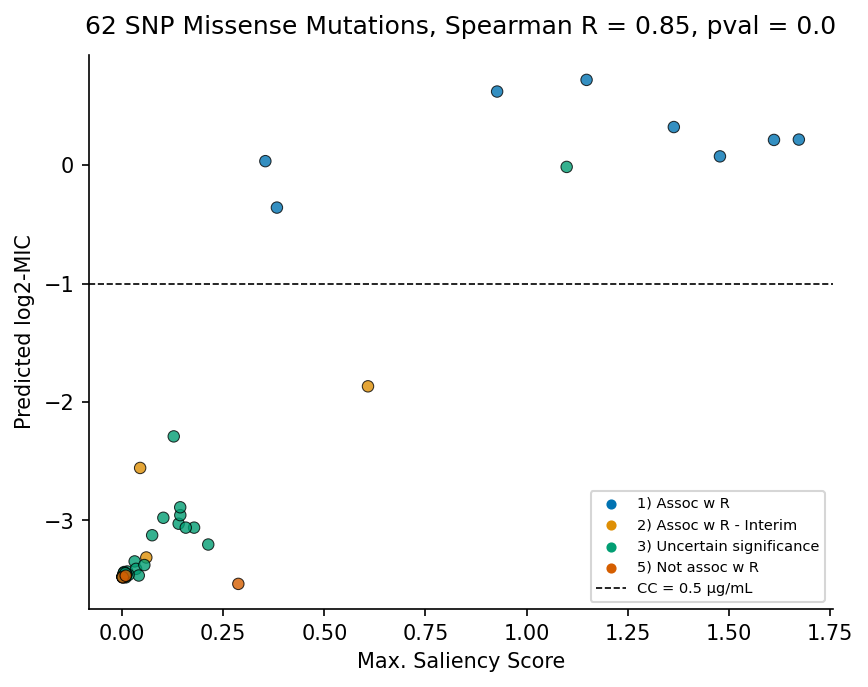

In [7]:
MXF_pred = pd.read_csv("../analysis/Moxifloxacin/insilico_mutagenesis/gyrBA_WHO_predictions.csv")

MXF_pred = plot_pred_MIC_by_saliency("MXF", MXF_pred, MXF_gyrBA_lineage_df, gyrBA_seqDict['gyrBA'], MXF_gyrBA_lineage_scores, saveName="../analysis/Moxifloxacin/insilico_mutagenesis/predictions_vs_saliency.png")

In [23]:
pos = 6742
print(f"Ref: {gyrBA_seqDict['gyrBA'].loc['MT_H37Rv', pos]}")
idx = MXF_gyrBA_lineage_df.query("Pos==@pos").index.values[0] 
max_scores = np.max(MXF_gyrBA_lineage_scores[:, :, idx, 0], axis=0)
max_scores_dict = dict(zip(BASE_TO_COLUMN.keys(), max_scores))
max_scores_dict

Ref: A


{'A': 0.0, 'C': 0.80232906, 'T': 0.0, 'G': 0.0, '-': 0.0}

# Lineage Saliency Plots

In [125]:
def generate_lineage_saliency_plot(drug, drug_abbr, out_dir, binary_thresh, sig_thresh=0.2, significance=True, binary=False, savefName=None):

    df_phenos = pd.read_csv(os.path.join(data_path, drug_abbr, "data_for_model.csv"))
    df_phenos["log2_MIC"] = np.log2(df_phenos[f"{drug_abbr}_midpoint"])
    mean_log_mic = np.mean(df_phenos["log2_MIC"])
    print(f"Mean MIC: {df_phenos[f'{drug_abbr}_midpoint'].mean()}, Mean log2-MIC: {mean_log_mic}")
    
    
    ################################### STEP 1: MAKE LINEAGE MATRIX ###################################
    
    
    lineages = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix_Coll2014.csv", index_col=[0])
    lineages.columns = lineages.columns.astype(int)
    assert len(np.unique(lineages.values)) == 2
    assert np.min(lineages.values) == 0

    # get only the training or testing set and subset the lineage matrix too
    lineages = lineages.loc[df_phenos["ROLLINGDB_ID"]]
    
    if binary:
        saliency_dir = os.path.join(out_dir, "saliency/binary")
    else:
        saliency_dir = os.path.join(out_dir, "saliency/quant")
        
    # get lineage scores for the primary model
    lineage_scores = np.load(os.path.join(saliency_dir, "lineage_scores.npy"))
    
    # create a dataframe with lineages, scores, and average log-MIC of isolates
    lineage_scores_df = pd.DataFrame({"position": lineages.columns, 
                                      "Max": lineage_scores.max(axis=0), 
                                      "Min": lineage_scores.min(axis=0)
                                     })
    
    lineage_scores_df = lineage_scores_df.merge(coll_2014[["#lineage", "position"]], on="position")
    lineage_scores_df.rename(columns={"#lineage":"Lineage"}, inplace=True)
    lineage_scores_df["Lineage"] = [val.replace("lineage", "") for val in lineage_scores_df["Lineage"].values]
    
    
    ################################### STEP 2: COMPUTE AVERAGE MIC OF EACH LINEAGE DIVIDED BY AVERAGE OF THE WHOLE DATASET ###################################


    lineage_scores_df['Mean_log2_MIC'] = mean_log_mic
    
    # add log2-MIC to get averaged per lineage later
    lineages = lineages.merge(df_phenos[["ROLLINGDB_ID", "log2_MIC"]].set_index("ROLLINGDB_ID"), left_index=True, right_index=True)

    # insilico_lineage_predictions = pd.read_csv(f"../analysis/{drug}/insilico_mutagenesis/lineage_predictions.csv")
    # lineage_scores_df = lineage_scores_df.merge(insilico_lineage_predictions, on="Lineage", how="inner")

    for i, row in lineage_scores_df.iterrows():

        # add average log2-MIC of isolates with that SNP
        log2_MIC = lineages.loc[lineages[row["position"]]==1]["log2_MIC"].mean()
        lineage_scores_df.loc[i, ["log2_MIC", "MIC"]] = [log2_MIC, np.exp2(log2_MIC)]
    
        # then perform a hypothesis test for MIC enrichment (greater or less than the mean)
        pos, lineage = str(row["position"]), row["Lineage"]

        isolates_in_lineage = lineage_mat.loc[df_phenos["ROLLINGDB_ID"].values].loc[lineage_mat[pos]==1].index.values

        # hypothesis test to compare mean of isolates in a particular lineage to the entire dataset
        if len(isolates_in_lineage) > 0:

            if log2_MIC > mean_log_mic:
                alt = "greater"
            else:
                alt = "less"

            mu_stat, mu_pval = st.mannwhitneyu(df_phenos.query("ROLLINGDB_ID in @isolates_in_lineage")[f"{drug_abbr}_midpoint"].values, 
                                               df_phenos[f"{drug_abbr}_midpoint"].values,
                                               alternative=alt,
                                              )

            lineage_scores_df.loc[i, "MIC_pval"] = mu_pval
        
        else:
            lineage_scores_df.loc[i, "MIC_pval"] = np.nan
        
        
    ################################### STEP 3: GET P-VALUES FOR USING PERMUTATION MODEL SCORES ###################################
    

    # get permutation score results
    if significance:

        lineage_scores_paths = glob.glob(os.path.join(saliency_dir, "permutation_test/mlp_scores*.npy"))
        assert len(lineage_scores_paths) == 10

        lineage_permute_max = [pd.Series(np.load(scores_path).max(axis=0)) for scores_path in lineage_scores_paths]
        lineage_permute_max = pd.concat(lineage_permute_max, axis=1).values

        lineage_permute_min = [pd.Series(np.load(scores_path).min(axis=0)) for scores_path in lineage_scores_paths]
        lineage_permute_min = pd.concat(lineage_permute_min, axis=1).values

        # get p-values from the permutation test
        for i, row in lineage_scores_df.iterrows():

            # for scores of 0, the p-value is often 0 because all the permuted values are also 0. This is a misleading p-value, so ignore them
            if row["Max"] > 0:
                lineage_scores_df.loc[i, "Max_pval"] = np.mean(lineage_permute_max[i, :] > row["Max"])
            else:
                lineage_scores_df.loc[i, "Max_pval"] = np.nan

            if row["Min"] < 0:
                lineage_scores_df.loc[i, "Min_pval"] = np.mean(lineage_permute_min[i, :] < row["Min"])
            else:
                lineage_scores_df.loc[i, "Min_pval"] = np.nan

        # _, mic_bh_pvals, _, _ = sm.multipletests(lineage_scores_df["MIC_pval"], method='fdr_bh', is_sorted=False, returnsorted=False)
        # lineage_scores_df["BH_MIC_pval"] = mic_bh_pvals
        lineage_scores_df["Bonferroni_MIC_pval"] = lineage_scores_df["MIC_pval"] * len(lineage_scores_df.loc[~pd.isnull(lineage_scores_df["MIC_pval"])])
        
        # assert len(lineage_scores_df.query("MIC_pval > BH_MIC_pval")) == 0
        assert len(lineage_scores_df.query("MIC_pval > Bonferroni_MIC_pval")) == 0
        
        significant_lineages = lineage_scores_df.query("(Max_pval < @sig_thresh & Max > 0) | (Min_pval < @sig_thresh & Min < 0)").reset_index(drop=True)

        # remove lineages where both are significant
        # significant_lineages = significant_lineages.query("~(Max_pval < @sig_thresh & Min_pval < @sig_thresh)")
        
        print(f"{len(significant_lineages)}/{len(lineage_scores_df)} lineages are significant")

    else:
        significant_lineages = lineage_scores_df.query("Max > 0 | Min < 0")
        print(f"{len(significant_lineages)}/{len(lineage_scores_df)} lineages have a non-zero score")

    # print(f"{len(significant_lineages.query('Bonferroni_MIC_pval < @sig_thresh'))}/{len(significant_lineages)} saliency-significant lineages have average MICs significantly different from the mean")
    # print(f"{len(significant_lineages.query('Bonferroni_MIC_pval < @sig_thresh'))}/{len(significant_lineages)} saliency-significant lineages have average MICs significantly different from the mean")

        
    ################################### STEP 4: CREATE AN AGGREGATE SALIENCY SCORE FOR EACH LINEAGE ###################################
    
    
    # combine Max and Min scores, into a single array, depending on the site
    for i, row in significant_lineages.iterrows():
        
        if significance:
              
            if row["Max_pval"] < sig_thresh:

                # if Max is significant, but not Min
                if pd.isnull(row["Min_pval"]) or row["Min_pval"] >= sig_thresh:
                    significant_lineages.loc[i, "plot_score"] = row["Max"]
                    significant_lineages.loc[i, "plot_score_pval"] = row["Max_pval"]

                # if both are significant, take the average
                # else:
                    # significant_lineages.loc[i, "plot_score"] = np.mean([row["Max"], row["Min"]])

                    # # arbitrarily take one of the p-values
                    # significant_lineages.loc[i, "plot_score_pval"] = row["Max_pval"]

            # if Max is not significant, but Min is
            elif row["Min_pval"] < sig_thresh:
                significant_lineages.loc[i, "plot_score"] = row["Min"]
                significant_lineages.loc[i, "plot_score_pval"] = row["Min_pval"]

            # there's no else because we already filtered to keep lineages that are significant in at least Max or Min
            else:
                continue
                
        else:
            if row["Max"] > np.abs(row["Min"]):
                significant_lineages.loc[i, "plot_score"] = row["Max"]
                significant_lineages.loc[i, "plot_score_pval"] = row["Max_pval"]
            else:
                significant_lineages.loc[i, "plot_score"] = row["Min"]
                
            
    
    ################################### STEP 5: FIT A LINEAR REGRESSION TO PLOT A LINE OF BEST FIT ###################################
    

    significant_lineages_MICs = significant_lineages.query('plot_score_pval < 0.05 & Bonferroni_MIC_pval < 0.05 & ((plot_score > 0 & log2_MIC > Mean_log2_MIC) | (plot_score < 0 & log2_MIC < Mean_log2_MIC))')
    print(f"{len(significant_lineages_MICs)} lineages have a significant saliency score and an average log2_MIC significantly different from the mean")

    # fit a linear regression
    yvar = "log2_MIC"

    if len(significant_lineages_MICs) == 0:
        plot_df = significant_lineages.copy()
    else:
        plot_df = significant_lineages_MICs.copy()
    
    X = plot_df["plot_score"].values.reshape(-1, 1)
    y = plot_df[yvar]

    linReg = LinearRegression(fit_intercept=True)
    linReg.fit(X, y)
    yhat = linReg.predict(X)
    print(f"Predicted log2-MIC for saliency = 0: {linReg.predict(np.array([0]).reshape(-1, 1))}")
    
    fig, ax = plt.subplots(figsize=(4, 4))
    plt.plot(np.squeeze(X), yhat, color="tomato", linewidth=0.5, zorder=1, )#label=f"y = {np.round(linReg.intercept_, 2)} + {np.round(linReg.coef_[0], 2)}x")
    
    sns.scatterplot(data=plot_df, x="plot_score", y=yvar, ax=ax, s=25, linewidth=0.5, edgecolor="black", zorder=2)

    right_adj = 0.025
    up_adj = 0.05
    
    label_thresh = 0
    
    for i, row in plot_df.iterrows():
        
        ax.text(row["plot_score"] + right_adj, row[yvar] + up_adj, row["Lineage"], color='black', fontsize=6)
            
        # if drug_abbr == "RIF" and row["Lineage"] == "4**":
        #     ax.text(row["plot_score"] + right_adj, row[yvar] - 0.15, row["Lineage"], color='black', fontsize=6)
        # elif drug_abbr == "MXF":
        #     if row["Lineage"] == "2.2":
        #         ax.text(row["plot_score"] - 0.1, row[yvar] + up_adj*1.5, row["Lineage"], color='black', fontsize=6)
        #     elif row["Lineage"] == "1.1":
        #         ax.text(row["plot_score"] + right_adj*2, row[yvar] - up_adj, row["Lineage"], color='black', fontsize=6)
        #     elif row["Lineage"] == "4.1.1":
        #         ax.text(row["plot_score"] + right_adj + 0.01, row[yvar] - up_adj, row["Lineage"], color='black', fontsize=6)
        #     elif row["Lineage"] in ["1.2.1", "4.1.2.1"]:
        #         ax.text(row["plot_score"] + right_adj*1.5, row[yvar] - up_adj*2, row["Lineage"], color='black', fontsize=6)
        #     elif row["Lineage"] in ["2.2.2", "4.6.1.2", "4.6.1", "1.1.1", "1.1.2"]:
        #         ax.text(row["plot_score"] + right_adj*1.5, row[yvar] + up_adj, row["Lineage"], color='black', fontsize=6)
        #     else:
        #         ax.text(row["plot_score"] + right_adj, row[yvar] + up_adj, row["Lineage"], color='black', fontsize=6)
        # else:
        #     ax.text(row["plot_score"] + right_adj, row[yvar] + up_adj, row["Lineage"], color='black', fontsize=6)
        
    #plt.scatter(0, mean_log_mic, label="Average log2-MIC", marker="*", color="yellow", edgecolor="black", linewidth=0.5, s=40, zorder=3)
    # plt.axhline(y=mean_log_mic, linestyle='--', linewidth=0.5, color='black', label=f'Avg. = {np.round(mean_log_mic, 2)}')
    
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    plt.yticks(ticks=ax.get_yticks(), labels=np.round(np.exp2(ax.get_yticks()), 2))
    plt.ylabel("Average MIC", fontsize=8)
    
    # plt.legend(fontsize=6, loc="lower right")
    plt.xlabel("Saliency Score", fontsize=8)
    sns.despine()
    
    corr_results = st.spearmanr(np.squeeze(X), y)
    
    plt.title(f"{drug} Model, Spearman R = {np.round(corr_results[0], 2)}, pval = {np.round(corr_results[1], 2)}", fontsize=10)
    
    if savefName is None:
        plt.show()
    else:
        plt.savefig(savefName, dpi=300)
        
    return significant_lineages

In [131]:
df_rif = pd.read_csv(os.path.join(data_path, "RIF", "data_for_model.csv"))

In [136]:
df_mxf.query("Coll2014=='2.2.2'").merge(df_rif.query("Coll2014=='2.2.2'")[['ROLLINGDB_ID', 'RIF_midpoint']], on='ROLLINGDB_ID')[['ROLLINGDB_ID', 'MXF_midpoint', 'RIF_midpoint']].sort_values('MXF_midpoint')

,ROLLINGDB_ID,MXF_midpoint,RIF_midpoint
40,ERR4828684,0.015,0.03
38,ERR4830411,0.015,0.03
32,ERR4831756,0.015,8.00
7,ERR4811144,0.015,0.09
23,ERR4811544,0.045,0.03
...,...,...,...
128,SAMN02360552,8.000,16.00
127,SAMN02398708,8.000,16.00
126,SAMN02360560,8.000,16.00
159,SAMN02398712,8.000,16.00


In [137]:
df_mxf_rif_combined = df_mxf.merge(df_rif[['ROLLINGDB_ID', 'RIF_midpoint']], on='ROLLINGDB_ID')[['ROLLINGDB_ID', 'MXF_midpoint', 'RIF_midpoint']]
df_mxf_rif_combined.shape

(6627, 3)

In [141]:
st.spearmanr(df_mxf_rif_combined['RIF_midpoint'], df_mxf_rif_combined['MXF_midpoint'])

SignificanceResult(statistic=0.3613011868481283, pvalue=1.5839872277898002e-203)

Mean MIC: 0.42809763394071254, Mean log2-MIC: -3.0667314626957918
57/62 lineages are significant
19 lineages have a significant saliency score and an average log2_MIC significantly different from the mean
Predicted log2-MIC for saliency = 0: [-3.45534788]


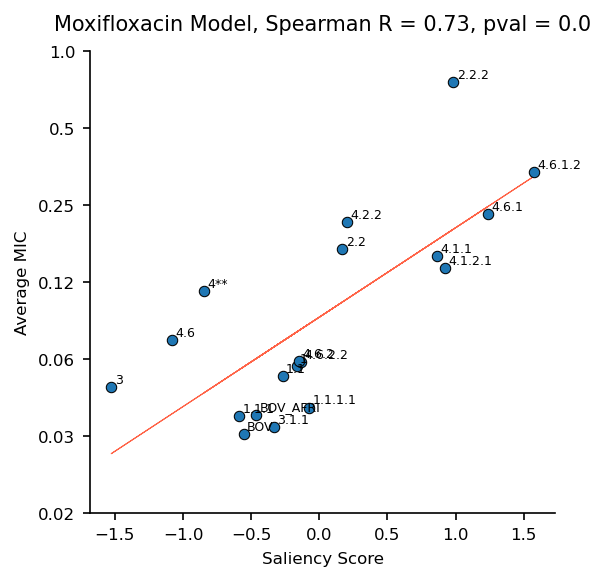

In [126]:
MXF_lineage_scores_df = generate_lineage_saliency_plot("Moxifloxacin",
                                                        "MXF", 
                                                       "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_gyrBA_lineage", 
                                                       binary_thresh=0.5,
                                                       sig_thresh=0.05,
                                                       significance=True,
                                                       binary=False, 
                                                       #savefName="../analysis/Moxifloxacin/insilico_mutagenesis/lineage_scatter.png"
                                                     )

Mean MIC: 1.0208727142857144, Mean log2-MIC: -1.2614637523802692
53/62 lineages are significant
7 lineages have a significant saliency score and an average log2_MIC significantly different from the mean
Predicted log2-MIC for saliency = 0: [-1.46900171]


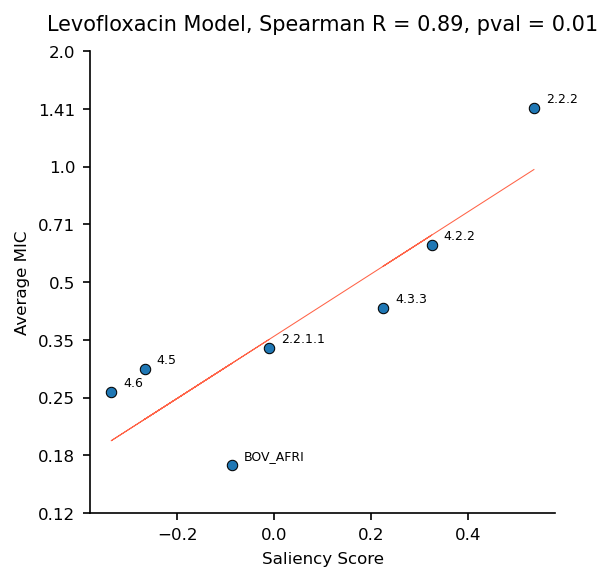

In [144]:
LEV_lineage_scores_df = generate_lineage_saliency_plot("Levofloxacin",
                                                        "LEV", 
                                                       "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/LEV_gyrBA_lineage", 
                                                       binary_thresh=1,
                                                       sig_thresh=0.05,
                                                       significance=True,
                                                       binary=False, 
                                                       #savefName="../analysis/Moxifloxacin/insilico_mutagenesis/lineage_scatter.png"
                                                     )

Mean MIC: 6.283871265616513, Mean log2-MIC: -0.9319754257635476
59/62 lineages are significant
14 lineages have a significant saliency score and an average log2_MIC significantly different from the mean
Predicted log2-MIC for saliency = 0: [-1.4747768]


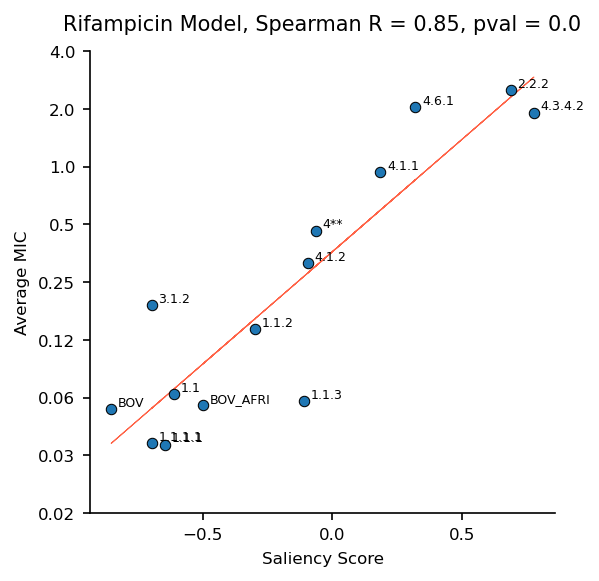

In [127]:
RIF_lineage_scores_df = generate_lineage_saliency_plot("Rifampicin",
                                                        "RIF", 
                                                       "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoABC_lineage", 
                                                       binary_thresh=0.5,
                                                       sig_thresh=0.05,
                                                       significance=True,
                                                       binary=False, 
                                                       #savefName="../analysis/Moxifloxacin/insilico_mutagenesis/lineage_scatter.png"
                                                     )

In [145]:
PZA_lineage_scores_df = generate_lineage_saliency_plot("Pyrazinamide",
                                                        "PZA", 
                                                       "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_4Loci_lineage", 
                                                       binary_thresh=100,
                                                       sig_thresh=0.05,
                                                       significance=True,
                                                       binary=False, 
                                                       #savefName="../analysis/Moxifloxacin/insilico_mutagenesis/lineage_scatter.png"
                                                     )

Mean MIC: 217.8448275862069, Mean log2-MIC: 6.441008957053313
38/62 lineages are significant
0 lineages have a significant saliency score and an average log2_MIC significantly different from the mean


ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

# Is MIC Significantly Elevated in Certain Lineages

In [299]:
RIF_sig_lineage_scores_df.query("Lineage in ['4.2.1', '2.2.1']")

,position,Max,Min,Lineage,Max_pval,Min_pval,BH_Max_pval,BH_Min_pval,log2-MIC,MIC_enrich_pval,BH_MIC_enrich_pval,plot_score
3,783601,-0.0,-0.393883,4.2.1,0.1,0.0,0.344444,0.0,0.510582,0.000498,0.001029,-0.393883
4,797736,-0.0,-0.223559,2.2.1,0.4,0.0,0.590476,0.0,-0.853869,0.457839,0.535586,-0.223559


In [287]:
RIF_sig_lineage_scores_df.query("BH_MIC_enrich_pval < 0.05")

,position,Max,Min,Lineage,Max_pval,Min_pval,BH_Max_pval,BH_Min_pval,log2-MIC,MIC_enrich_pval,BH_MIC_enrich_pval,plot_score
1,346693,0.741299,0.000000,2.2.2,0.0,0.6,0.000000,0.676364,1.292509,6.141254e-16,4.759472e-15,0.741299
2,514245,0.691994,0.000000,4.1.1,0.0,0.6,0.000000,0.676364,-0.111073,8.549601e-06,2.304675e-05,0.691994
6,1882180,-0.000000,-0.669186,BOV_AFRI,0.6,0.0,0.641379,0.000000,-4.199761,5.087022e-06,1.470124e-05,-0.669186
7,2831482,-0.000000,-0.655679,BOV,0.6,0.0,0.641379,0.000000,-4.199761,5.087022e-06,1.470124e-05,-0.655679
8,3021283,-0.000000,-0.317414,1.1.1,0.3,0.0,0.581250,0.000000,-4.897060,2.157014e-53,4.457829e-52,-0.317414
9,3216553,-0.000000,-0.364554,1.1.1.1,0.5,0.0,0.620000,0.000000,-4.959214,9.729504e-46,1.508073e-44,-0.364554
12,4260268,0.444209,0.000000,4.6.1,0.0,0.9,0.000000,0.914754,1.988988,1.512227e-06,5.515181e-06,0.444209
13,4404247,-0.000000,-0.363112,1.1,0.5,0.0,0.620000,0.000000,-4.045164,1.138472e-65,7.058529e-64,-0.363112


In [ ]:
# nice! does not co-occur with canonical gyrBA mutations
plot_variant_mics("gyrBA", 7566, moxi_gyrBA_seq_dict, df_moxi, isolates_with_gyrBA_mut, title="../Figures/gyrBA_7566_mic_dist.png")

In [ ]:
# too few isolates: only 5 with gyrBA or the variant at all. Also not convincing with the shift
# plot_variant_mics("gyrBA", 7521, moxi_gyrBA_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
# not super convincing. 22 total isolates, but gyrBA variants seem to be higher
# 6735, 6737, 6749
plot_variant_mics("gyrBA", 6735, moxi_gyrBA_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
plot_variant_mics("gyrBA", 8164, moxi_gyrBA_seq_dict, df_moxi, isolates_with_gyrBA_mut, title="../Figures/gyrBA_8164_mic_dist.png")

# Moxifloxacin Multiloci Models

In [ ]:
# moxi_gyrBA_6Loci_df, moxi_gyrBA_6Loci_seq_dict = generate_saliency_plots("config_moxi_6Loci.yaml",
#                                                              ["MXF"],
#                                                              cat_to_check=["1", "2"],
#                                                              binary=False,
#                                                              isolate_variants_df=None,
#                                                              num_bootstrap=1, 
#                                                              save=True
#                                                             )

# Bedaquiline

In [ ]:
# bdq_no_lineage_df, bdq_no_lineage_seq_dict = generate_saliency_plots("config_bdq_old.yaml",
#                                                              ["BDQ"],
#                                                              cat_to_check=["1", "2"],
#                                                              binary=False,
#                                                              isolate_variants_df=None,
#                                                              num_bootstrap=1, 
#                                                              save=True
#                                                             )

In [ ]:
who_single_drug = who_variants.query("drug=='RIF'")

who_pos = who_single_drug["genome_index"].str.split(",", expand=True)
who_pos.columns = ["pos1", "pos2"]

who_single_drug = pd.concat([who_single_drug, who_pos], axis=1).reset_index(drop=True)
print(who_single_drug.shape)

In [ ]:
for i, row in who_single_drug.iterrows():
    
    if not pd.isnull(row["pos2"]):
        
        # duplicate the row and make pos1 to pos2 in the duplicate
        add_row = who_single_drug.iloc[i, :]
        add_row["pos1"] = row["pos2"]
        
        who_single_drug = pd.concat([who_single_drug, pd.DataFrame(add_row).T], axis=0)
        
who_single_drug = who_single_drug.reset_index(drop=True)
del who_single_drug["pos2"]
del who_single_drug["genome_index"]
print(who_single_drug.shape)
who_single_drug.rename(columns={"pos1": "Pos"}, inplace=True)
who_single_drug["Pos"] = who_single_drug["Pos"].astype(float).astype(object)

In [ ]:
# get all sites with positive saliency scores
rif_resistance_analysis = rif_rpoBC_df.query("Max > 0 & max_pVal < 0.05").merge(who_single_drug, on="Pos", how="outer").sort_values("Max", ascending=False)

rif_resistance_analysis = rif_resistance_analysis.query("gene in ['rpoB', 'rpoC']").reset_index(drop=True)

del rif_resistance_analysis["Unnamed: 0"]
print(rif_resistance_analysis.shape)

#new_pos = rif_resistance_analysis.query("confidence in ['3) Uncertain significance', '5) Not assoc w R']")
new_pos = rif_resistance_analysis.loc[(~pd.isnull(rif_resistance_analysis["Max"])) & (rif_resistance_analysis["confidence"] == '3) Uncertain significance')]

print(new_pos.shape)

In [ ]:
for i, row in new_pos.iterrows():
    
    ref = rif_rpoBC_seq_dict["rpoBC"].loc["MT_H37Rv", row["Pos"]]
    alt = rif_rpoBC_seq_dict["rpoBC"][row["Pos"]] != ref
    new_pos.loc[i, "Num_Isolates"] = sum(alt)
    
# new_pos = new_pos.query("Num_Isolates > 5").reset_index(drop=True)
new_pos["Num_Isolates"] = new_pos["Num_Isolates"].astype(int) 
print(new_pos.shape)

In [ ]:
new_pos.sort_values(["Num_Isolates", "Max"], ascending=False)

In [ ]:
drug = "RIF"
locus = "rpoBC"
pos = 761880.0
cc = 0.5

for _, row in new_pos.drop_duplicates("Pos").sort_values(["Num_Isolates", "Max"], ascending=False).iterrows():
    plot_variant_mics(drug, locus, row["Pos"], rif_rpoBC_seq_dict, df_rif, isolates_with_rpoBC_mut, cc, title=None)

In [ ]:
# rif_rpoABC_df, rif_rpoABC_seq_dict = generate_saliency_plots("config_rif_multiLoci.yaml",
#                                                              ["RIF"],
#                                                              cat_to_check=["1", "2"],
#                                                              binary=False,
#                                                              isolate_variants_df=None,
#                                                              num_bootstrap=1, 
#                                                              save=True
#                                                             )

In [ ]:
# drug = "RIF"
# locus = "rpoA"
# pos = 3878575.0
# cc = 0.5

# plot_variant_mics(drug, locus, pos, rif_rpoABC_seq_dict, df_rif, isolates_with_rpoBC_mut, cc, title=None)

In [ ]:
# rif_rpoABC_Rv2752c_df, rif_rpoABC_Rv2752c_seq_dict = generate_saliency_plots("config_rif.yaml",
#                                                                              ["RIF"],
#                                                                              cat_to_check=["1", "2"],
#                                                                              binary=False,
#                                                                              isolate_variants_df=None,
#                                                                              num_bootstrap=1, 
#                                                                              save=True
#                                                                             )

In [ ]:
# rif_rpoBC_lineage_df, rif_rpoBC_lineage_seq_dict = generate_saliency_plots("config_rif_lineage.yaml",
#                                                              ["RIF"],
#                                                              cat_to_check=["1", "2"],
#                                                              binary=False,
#                                                              isolate_variants_df=None,
#                                                              num_bootstrap=1, 
#                                                              save=True
#                                                             )

In [ ]:
def two_sample_mean_bootstrap(variant_mics, no_variant_mics, num_bootstrap=1000):
    '''
    Want log2(fold change) > 1. 
    '''
    
    if len(variant_mics) > 0 and len(no_variant_mics) > 0:
        bs_res = []
        #test_stat = np.mean(variant_mics) - np.mean(no_variant_mics)
        test_stat = np.log2(np.mean(variant_mics) / np.mean(no_variant_mics))

        # do bootstrapping of difference in means. Randomly sample isolates from the two groups, then compute the mean difference in MIC between them
        for _ in range(num_bootstrap):

            # draw bootstraps
            variant_sample = np.random.choice(variant_mics, np.max([len(variant_mics), num_bootstrap]), replace=True)
            no_variant_sample = np.random.choice(no_variant_mics, np.max([len(no_variant_mics), num_bootstrap]), replace=True)

            # get the test statistic and add it to a running list
            #stat = np.mean(variant_sample) - np.mean(no_variant_sample)
            stat = np.log2(np.mean(variant_sample) / np.mean(no_variant_sample))
            bs_res.append(stat)
    else:
        test_stat = np.nan
        bs_res = np.ones(num_bootstrap) * np.nan
        
    return test_stat, np.array(bs_res)

In [ ]:
def plot_variant_mics(drug, locus, variant, mat_seq_dict, df_phenos, isolates_with_canonical_mut, cc, title=None):
    
    # sns.color_palette("Set2").as_hex()[0]
    palette = "Set1"
    color_dict = {"no variants": sns.color_palette(palette).as_hex()[-1], 
                  "variant only": sns.color_palette(palette).as_hex()[1],
                  "canonical mut only": sns.color_palette(palette).as_hex()[4],
                  "canonical mut + variant": sns.color_palette(palette).as_hex()[0]
                 }
        
    ref = mat_seq_dict[locus].loc["MT_H37Rv", variant]
    isolates_with_variant = mat_seq_dict[locus].loc[mat_seq_dict[locus][variant] != ref, variant].index.values
    
    isolates_both = list(set(isolates_with_canonical_mut).intersection(isolates_with_variant))
    isolates_variant_only = list(set(isolates_with_variant) - set(isolates_with_canonical_mut))
    isolates_canonical_only = list(set(isolates_with_canonical_mut) - set(isolates_with_variant))
    
    isolates_nothing_1 = list(set(df_phenos["ROLLINGDB_ID"]) - set(isolates_both) - set(isolates_variant_only) - set(isolates_canonical_only))
    isolates_nothing_2 = list(set(df_phenos["ROLLINGDB_ID"]) - set(isolates_with_canonical_mut) - set(isolates_with_variant))
    assert len(isolates_nothing_1) == len(isolates_nothing_2) == len(set(isolates_nothing_1).intersection(isolates_nothing_2))
        
    df_phenos.loc[df_phenos["ROLLINGDB_ID"].isin(isolates_nothing_1), "Variant"] = 'no variants'
    df_phenos.loc[df_phenos["ROLLINGDB_ID"].isin(isolates_both), "Variant"] = 'canonical mut + variant'
    df_phenos.loc[df_phenos["ROLLINGDB_ID"].isin(isolates_variant_only), "Variant"] = 'variant only'
    df_phenos.loc[df_phenos["ROLLINGDB_ID"].isin(isolates_canonical_only), "Variant"] = 'canonical mut only'
                            
    # print("There are no isolates without canonical variants, but with the variant of interest")
    if ~('variant only' not in df_phenos["Variant"].value_counts().index.values):
        df_phenos["log-MIC"] = np.log(df_phenos[f"{drug}_midpoint"])
        if (len(df_phenos.query("Variant == 'variant only'")) > 0) & (len(df_phenos.loc[(df_phenos["Variant"] == 'variant only') & (df_phenos[f"{drug}_midpoint"] > cc)]) > 1):
            print(df_phenos.groupby("Variant")[f"{drug}_midpoint"].mean())
            print(df_phenos["Variant"].value_counts())

            fig, ax = plt.subplots(1, 1, figsize=(12, 4))
            g = sns.histplot(data=df_phenos, x="log-MIC", hue='Variant', 
                             stat='probability', common_norm=False, multiple='dodge', 
                             hue_order=["no variants", 'canonical mut only', "variant only", 'canonical mut + variant'], 
                             palette=color_dict, ax=ax)

            plt.xlabel("MIC (μg/mL)")
            plt.xticks(ticks=ax.get_xticks(), labels=np.round(np.exp(ax.get_xticks()), 2).astype(str))
            ax.set_title(f"{drug} MIC Distribution for Variants at Position {int(variant)}")

            sns.move_legend(ax, "upper left", title=None)
            sns.despine()

            if title is None:
                plt.show()
            else:
                plt.savefig(title, dpi=300)
        # else:
        #     print(f"There are no isolates with only a variant at {variant}")

In [ ]:
def filter_saliencies(saliency_df, mat_seq_dict, drug, df_phenos):
    
    # get positions with non-zero scores
    nonZero = saliency_df.query("Max != 0 | Min != 0")
    
    # find the number of isolates with 
    for i, row in nonZero.iterrows():
        df = mat_seq_dict[row["Gene"]]
        if len(df[row["Pos"]].unique()) > 1:
            nonZero.loc[i, "Variant"] = 1
        else:
            nonZero.loc[i, "Variant"] = 0

    nonZero_analysis = nonZero.query("Variant == 1").sort_values("Max", ascending=False)
    
    for i, row in nonZero_analysis.iterrows():

        gene = row["Gene"]
        pos = row["Pos"]
        ref = mat_seq_dict[gene].loc["MT_H37Rv", pos]

        isolates_with_variant = mat_seq_dict[gene].loc[mat_seq_dict[gene][pos] != ref, pos].index.values

        if len(isolates_with_variant) >= 5:
            phenos_variant = df_phenos.query("ROLLINGDB_ID in @isolates_with_variant")[f"{drug}_midpoint"].values
            phenos_no_variant = df_phenos.query("ROLLINGDB_ID not in @isolates_with_variant")[f"{drug}_midpoint"].values

            stat, bootstrap_reps = two_sample_mean_bootstrap(phenos_variant, phenos_no_variant, num_bootstrap=100)
            lower, upper = np.percentile(bootstrap_reps, q=[2.5, 97.5])

            nonZero_analysis.loc[i, ["log2_FC", "log2_FC_LB", "log2_FC_UB"]] = stat, lower, upper
        else:
            nonZero_analysis.loc[i, ["log2_FC", "log2_FC_LB", "log2_FC_UB"]] = np.nan, np.nan, np.nan
            
    return nonZero_analysis.dropna(axis=0, how="any")

In [ ]:
df_moxi.query("gyrBA_mut==0").to_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/20220929_no_gyrBACanonicalMut.csv", index=False)

In [ ]:
test = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/20220929_no_gyrBACanonicalMut.csv")

In [ ]:
test.shape

In [ ]:
4819/(4819+1198)

In [ ]:
1198/(4819+1198)

In [ ]:
df_moxi.query("gyrBA_mut==0").groupby("category")["MOXI_midpoint"].mean()

In [ ]:
df_moxi.query("ROLLINGDB_ID not in @isolates_with_gyrBA_mut").MOXI_midpoint.max()

In [ ]:
df_moxi.query("ROLLINGDB_ID in @isolates_with_gyrBA_mut").MOXI_midpoint.max()

In [ ]:
#plot_variant_mics("Rv3361c_Rv3365c", 3774261, moxi_4Loci_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
#plot_variant_mics("Rv3561_Rv3565", 4005357.0, moxi_4Loci_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
#plot_variant_mics("Rv3561_Rv3565", 4004893.0, moxi_4Loci_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
moxi_isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/isolate_variants.csv")

# Moxifloxacin Multi-Loci

In [ ]:
locus_list = ['gyrBA', 'Rv0981_Rv0984', 'Rv3361c_Rv3365c', 'Rv3561_Rv3565'] 
moxi_4loci_df, moxi_4Loci_seq_dict = generate_saliency_plots("MOXI", 
                                                                 locus_list, 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/20220928_moxi_4Loci", 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/fastas", 
                                                                 ["MXF"], 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/20220902_data_clean.csv",
                                                                 cat_to_check=["1", "2"],
                                                                 isolate_variants_df=None,
                                                                 num_bootstrap=1000, 
                                                                 save=False
                                                                )

In [ ]:
locus_list = ['gyrBA', 'Rv0981_Rv0984', 'Rv2836c_Rv2837c', 'Rv3361c_Rv3365c', 'Rv0014c_Rv0015c', 'arfABC', 'phoPR', 'mbtK', 'Rv3561_Rv3565', 'stp', 'Rv0053_Rv0058', 'ligD_Rv0939'] 
# definitely remove: phoPR, stp, mbtK, Rv2836c_Rv2837c (dinF)
# next tier: arfABC, Rv0014c_Rv0015c

# generally good agreement between low saliency and not much contribution to MAE reduction

moxi_12loci_df, moxi_12Loci_seq_dict = generate_saliency_plots("MOXI", 
                                                                 locus_list, 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/20220907_moxi_12Loci", 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/fastas", 
                                                                 ["MXF"], 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/20220902_data_clean.csv",
                                                                 cat_to_check=["1", "2"],
                                                                 isolate_variants_df=None,
                                                                 num_bootstrap=1000, 
                                                                 save=False
                                                                )

# Analysis of Positions from Multi-Gene Model

In [ ]:
def validate_with_MIC_dist(locus, variant_col, mat_seq_dict, df_phenos, isolates_with_gyrBA_mut, num_bootstrap=1000):
    
    # check for significantly positive confidence intervals for all 3 groups -- isolates with canonical gyrBA mutations, isolates without, and all isolates
    ci_no_gyrBA, ci_gyrBA = plot_variant_mics(locus, variant_col, mat_seq_dict, df_phenos, isolates_with_gyrBA_mut, num_bootstrap=num_bootstrap, plot=False)
    #ci_all = plot_variant_mics_full_dist(locus, variant_col, mat_seq_dict, df_phenos, plot=False)
    
    # if at least one of them is significantly positive, keep that variant    
    cis_lst = [ci_no_gyrBA, ci_gyrBA]
    
    sig_bool = False
    for ci in cis_lst:
        
        if ci[0] > 0 and ci[1] > 0:
            sig_bool = True
            break
            
    if sig_bool:
        return 1
    else:
        return 0

In [ ]:
def filter_saliencies_by_seq_quality(var, gene, seq_dict, isolate_variants_df):
    
    ref_allele = seq_dict[gene].loc["MT_H37Rv", var]
    alt_alleles = seq_dict[gene].loc[seq_dict[gene][var] != ref_allele, var].unique()
    
    if type(var) in [float, int]:
        print("Pos found")
        # more than half of the variants must have passed QC
        if isolate_variants_df.query("POS == @var").QC.fillna(0).mean() > 0.5:
            # print(isolate_variants_df.query("POS == @var").QC.value_counts())
            print(isolate_variants_df.query("POS == @var").Isolate.unique())
        
    elif var.isnumeric():
        print("Pos found")
        print(isolate_variants_df.query("POS == @var").Isolate.unique())
        
    # insertion relative to H37Rv
    else:  
        if ref_allele == '-':
            var_pos = np.where(seq_dict[gene].columns == var)[0][0]
            prev_pos = seq_dict[gene].columns[var_pos-1]
            
            if isolate_variants_df.query("POS == @prev_pos").QC.fillna(0).mean() > 0.5:
                # print(isolate_variants_df.query("POS == @var").QC.value_counts())
                print(isolate_variants_df.query("POS == @prev_pos").Isolate.unique())

## The next 2 cells aren't needed because they don't significantly improve interpretation of results

In [ ]:
# # Merging promoters for plus strand
# promoter_location_data1 = pd.read_csv("../inputs/promoters_plus_strand.csv")
# data = promoter_location_data1.sort_values("upstream")[["downstream_gene", "position_upstream", "site", "upstream", "downstream"]]
# output_data =  []
# tracked_row = list(data.iterrows())[0][1]
# current_end = 74

# for idx, row in data.iterrows():

#     if row.upstream <= current_end:
#         # merging triggered
#         current_end = row.downstream
#     else:
#         tracked_row["downstream"] = current_end
#         output_data.append(tracked_row)
#         tracked_row = row
#         current_end = row.downstream
        
# output_data = pd.DataFrame(output_data)  
# output_data = output_data.iloc[1::,]
# print(len(data), len(output_data))
# promoter_location_data1= output_data

# # Merging promoters for minus strand
# promoter_location_data2 = pd.read_csv("../inputs/promoters_minus_strand.csv")
# data = promoter_location_data2.sort_values("upstream")[["downstream_gene", "position_upstream", "site", "upstream", "downstream"]]
# data = data.rename({
#     "upstream": "downstream",
#     "downstream": "upstream"
# }, axis = 1)
# output_data =  []
# tracked_row = list(data.iterrows())[0][1]
# current_end = 0

# for idx, row in data.iterrows():

#     if row.upstream <= current_end:
#         # merging triggered
#         current_end = row.downstream
#     else:
#         tracked_row["downstream"] = current_end
#         output_data.append(tracked_row)
#         tracked_row = row
#         current_end = row.downstream
        
# output_data = pd.DataFrame(output_data)  
# output_data = output_data.iloc[1::,]
# output_data = output_data.rename({
#     "upstream": "downstream",
#     "downstream": "upstream"
# }, axis = 1)
# print(len(data), len(output_data))
# promoter_location_data2= output_data

In [ ]:
# Add promoter annotations to genome
# H37Rv Genome

# for idx,row in promoter_location_data1.iterrows():
#     #Plus strand promoters
#     annotate_biopython_record(record, location=(
#         row.upstream, row.downstream, 1
#     ), feature_type="promoter")
    
# for idx,row in promoter_location_data2.iterrows():
#     #Plus strand promoters
#     annotate_biopython_record(record, location=(
#         row.downstream, row.upstream, -1
#     ), feature_type="promoter")